#  Point-Cloud Acrobatics: From Raw LiDAR to Stunning 3D Visuals
###### by Tomaž Žagar and Alen Mangafić - tomaz.zagar and alen.mangafic monkey gis.si

Dive into the fascinating world of LiDAR data as we transform raw point clouds into striking 3D visualizations using a suite of open-source tools. This workshop begins by exploring the ASPRS standard, helping you understand essential concepts like point classifications, return numbers, and other fundamental attributes that define LiDAR data. You’ll learn how to correctly interpret these attributes, assess data quality, and leverage them for more insightful analysis.

Moving beyond the basics, we’ll dig into powerful open-source workflows with PDAL, GRASS, WhiteboxTools for data reading, manipulation and spatial processing, and with tools like QGIS, Potree and pybabylonjs for dynamic 3D rendering. We’ll also introduce TileDB as a robust storage option to manage point-clouds as massive dataframes. Along the way, we’ll tackle real-world tasks like gridding, interpolation, vectorization, and classification, highlighting effective approaches to manage and visualize large-scale point clouds in a reproducible manner.

By integrating Python scripts with these specialized tools, you’ll discover how to automate complex processing chains and generate stunning outputs that bring your LiDAR data to life. While basic Python knowledge is helpful, it’s not mandatory — anyone eager to learn new techniques can follow along. By the end of this hands-on workshop, you’ll not only grasp the core concepts behind LiDAR data but also have the practical skills to handle and present it in exciting, visually compelling ways.

### Set up your python interprter (VS Codium example) ...

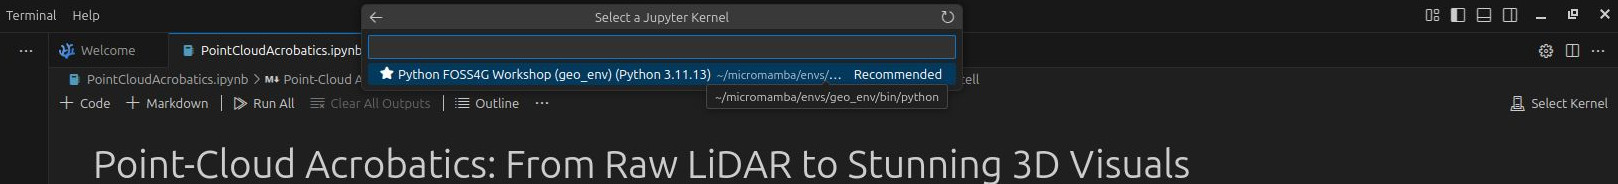

### ... or open GRASS from your `pcl` environment and run `juypter notebook` via icon or in the GRASS console

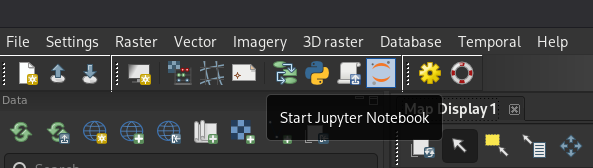 
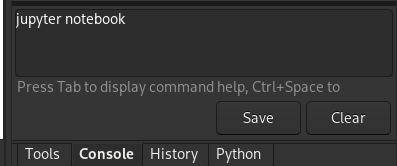

### This workshop runs on at least three different platforms and uses the latest tools. We do our best to spot problems and find solutions before the workshop, but we cannot test every tool on every computer and software version. So, a few unexpected issues may still pop up along the way!


## 1 LiDAR Fundamentals & Data Standards

## 1.1 What is LiDAR & Why It's Really Cool

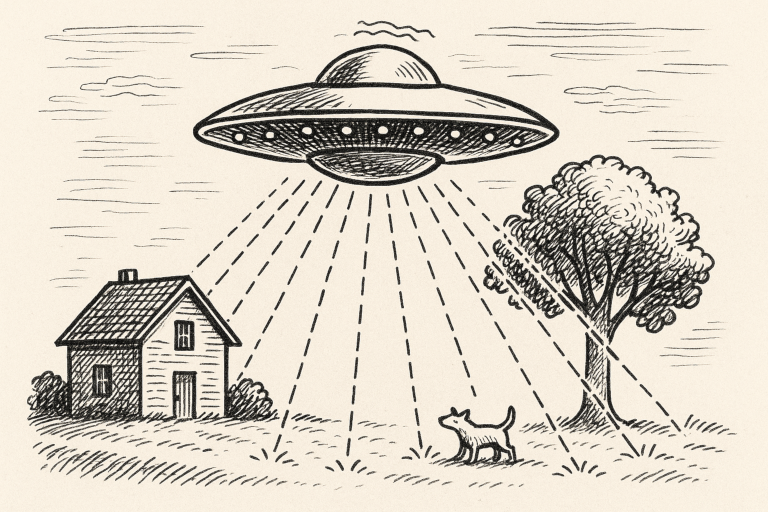

**LiDAR (Light Detection and Ranging)** is a remote sensing technology that uses laser pulses to measure distances to objects. It’s widely used in various industries and applications:

- **Cars** for obstacle detection and autonomous navigation  
- **Tractors** for precision agriculture  
- **Industrial robots** for mapping and collision avoidance  
- **Bathymetry** (shallow water mapping) using green-wavelength LiDAR  
- **But in our context**, we focus on **airborne LiDAR**

---

#### Core Principles

- **Pulsed Laser**: A LiDAR sensor emits rapid pulses of laser light (commonly near-infrared or green for bathymetry).
- **Time-of-Flight**: The time it takes for each pulse to return from a surface is used to compute distance.
- **Point Cloud Generation**: These distances, combined with GNSS/IMU data, are converted into 3D coordinates, resulting in a georeferenced point cloud.

---

#### Key Advantages

- **Canopy Penetration**: Airborne LiDAR can measure ground elevation even beneath vegetation.
- **High Accuracy**: Provides centimeter-level horizontal and vertical resolution.
- **3D Structure Capture**: Enables analysis of complex terrain, vegetation layers, and built environments.
- **Multiple Returns**: Each pulse can return multiple echoes (e.g. treetop, understory, ground), revealing vertical structure.
- **Full-Waveform Capture**: Advanced systems record the entire return signal shape-not just points-nabling better object differentiation.
- **Discrete Returns**: Most commonly used format—represents what we "see" in practice; it’s a simplified, efficient transformation of the full signal.

LiDAR captures the world as structured 3D data - penetrating through vegetation, mapping underwater terrain (in bathymetric setups), and preserving the spatial complexity of natural and urban environments. It’s not just about points - it’s about understanding the surfaces and volumes they represent.


- Question: What is the difference between a DSM and a DTM?

## 1.2 Anatomy of a Point Cloud

Point clouds are collections of 3D points in space that represent the geometry of physical objects or environments. They are commonly used in LiDAR (Light Detection and Ranging) data collection, and understanding their anatomy is crucial for effective analysis. In this chapter, we will dive deep into the **essential attributes** of point clouds, the **ASPRS classification scheme**, the differences between **LAZ** and **LAS** formats, the **compression battle**, and the revolutionary **COPC** format.

## Essential Attributes: Classification, Return Number, Intensity, RGB, NIR, GPS Time, Scan Angle

### Classification
**Classification** is one of the most important attributes in a point cloud. It refers to the assignment of a label to each point in the cloud based on its characteristic or the object it represents. 

The **ASPRS Classification Scheme** is a standardized classification system used to categorize LiDAR points based on their characteristics. It provides a consistent way to describe the objects that each point represents.
https://www.asprs.org/wp-content/uploads/2019/03/LAS_1_4_r14.pdf

In the meantime, R00 for LAS 1.5 was published [here](https://asprsorg.sharepoint.com/sites/PublicAccess/Shared%20Documents/Forms/AllItems.aspx?id=%2Fsites%2FPublicAccess%2FShared%20Documents%2FPublic%5FDocuments%2FStandards%2FLAS%2Fasprs%5Flas%5Fformat%5Fv15%5Fr00%5F2025%2Epdf&parent=%2Fsites%2FPublicAccess%2FShared%20Documents%2FPublic%5FDocuments%2FStandards%2FLAS&p=true&ga=1).


### Common Classifications:
- **Class 1**: Unclassified
- **Class 2**: Ground
- **Class 3**: Low Vegetation
- **Class 4**: Medium Vegetation
- **Class 5**: High Vegetation
- **Class 6**: Building
- **Class 7**: Low Point (Noise)
- **Class 8**: Model Key Points
- **Class 9**: Water
- **Class 10**: Reserved for future use

These classes help distinguish between different objects and surfaces, making it easier to analyze and process point cloud data. Understanding these classes is essential for effective classification, feature extraction, and visualization.
Other classifications include **power lines**, **bridges** and many more.

**Important**:
- **ground doesn't mean bare soil!**
- **vegetation classes are not standardised in means of height!**

---

### Return Number
LiDAR systems usually emit multiple laser pulses that can reflect off different surfaces before returning to the sensor. The **return number** is an integer value that identifies the order of a specific pulse’s reflection. 
- **First return**: The first surface hit (often the top of vegetation or buildings).
- **Last return**: The last surface hit (often the ground surface).
- **Intermediate returns**: Additional surfaces that the pulse encounters between the first and last return.

The **return number** helps to separate points based on the surface type they represent.

---

### Intensity
**Intensity** refers to the strength of the returned signal from the LiDAR pulse. The intensity value is typically proportional to the amount of light that the surface reflects back to the sensor, which can vary based on the material, surface roughness, and angle of incidence. Intensity values can be used to classify the type of surface (e.g., water, vegetation, roads).

---

### GPS Time
**GPS time** is the timestamp indicating when the LiDAR sensor collected the point. This attribute can be crucial when working with time-dependent data, such as tracking changes over time or aligning data from multiple LiDAR scans. GPS time provides context for the point cloud data by linking each point to a specific moment in time.

### RGB
**RGB** values represent the color of each point in the point cloud. When LiDAR sensors are equipped with cameras or other imaging systems, they can capture the color of the points along with their spatial position. This information is stored in **Red, Green, Blue (RGB)** channels, similar to how colors are represented in digital images. RGB data can add realism to 3D visualizations and can be useful in distinguishing different features in the landscape.

### NIR
**NIR (Near Infrared)** refers to the reflectance of points in the near-infrared spectrum. Some LiDAR systems capture NIR data in addition to RGB, providing an extra layer of information about vegetation and other surfaces. NIR is particularly useful for distinguishing vegetation from other types of land cover, as plants reflect more in the near-infrared spectrum than other surfaces. This data can be used in vegetation classification, health monitoring, and land use analysis.

---

### Scan Angle
**Scan Angle** refers to the angle at which the LiDAR sensor scans the surface during data collection. It is an important attribute that helps to understand the sensor’s position and orientation relative to the target surface. The scan angle can affect the accuracy and density of the point cloud, as points acquired at extreme angles may have lower precision. The scan angle is typically recorded for each point and can be used in post-processing to correct distortions and enhance the quality of the data.

## 1.3 Data Formats Deep Dive

LiDAR data is typically stored in either **LAS** or **LAZ** formats. These formats are designed to store point cloud data efficiently and are widely supported by various software packages.

### LAS (LiDAR Data Exchange Format)
The **LAS format** is a standard for storing LiDAR point cloud data. It stores raw data, including coordinates, classification, intensity, return number, and other attributes. It is uncompressed, making it easy to read and access but larger in size compared to compressed formats.

### LAZ (Compressed LiDAR Format)
**LAZ** is the compressed version of the LAS format. It uses a lossless compression algorithm to reduce the file size without losing any data. LAZ files can be up to 80% smaller than LAS files, making them more suitable for storage and transmission over networks. However, compression adds some processing overhead when reading the data.

Point clouds are inherently **dense** and **continuous** in 3D space, making them well-suited for tasks like 3D modeling, terrain analysis, and environmental monitoring. However, converting them into vector formats requires specialized algorithms that handle the high density and complexity of the data.

---

## Compression Battle: LAZ vs. LAS (Size vs. Processing Tradeoffs)

The choice between **LAZ** and **LAS** often comes down to a trade-off between file size and processing speed:

- **LAZ** offers significant **compression** and is ideal for large datasets that need to be transmitted or stored efficiently. However, it requires more processing time to decompress and read the data.
- **LAS** is **uncompressed**, making it easier and faster to read and process but at the cost of larger file sizes.

The choice between LAZ and LAS depends on the specific needs of the project. If data transmission speed and storage are the primary concerns, LAZ is the way to go. If processing speed and direct access to raw data are more important, LAS may be more suitable.

---

## COPC Revolution

The **COPC** (Cloud-Optimized Point Cloud) format represents a significant advancement in point cloud storage, offering a more efficient way to store and stream point cloud data over the web. COPC is optimized for **cloud storage**, making it ideal for **cloud-based workflows** and streaming applications.

### Virtual Tiling Concept (Spatial Indexing)
COPC uses **virtual tiling**, which divides the point cloud into small, manageable chunks or tiles. This approach allows for **spatial indexing**, enabling fast retrieval of only the relevant tiles needed for processing or visualization. Virtual tiling significantly reduces the amount of data that needs to be loaded into memory at any given time, improving performance.

### Octree Structure Explained
The **octree structure** is a hierarchical method for spatially organizing 3D point clouds. It divides the space into octants (eight regions), and each octant can be subdivided further as needed. This structure allows for efficient storage and retrieval of point cloud data, especially when combined with virtual tiling. Octrees enable fast access to specific regions of the point cloud, making them ideal for cloud-based applications where fast streaming and processing are critical.

### Cloud-Optimized Streaming Benefits
COPC’s cloud-optimized structure offers several benefits for streaming large point clouds:
- **Efficient data transfer**: Only the necessary tiles are streamed, reducing the amount of data transferred.
- **Scalability**: COPC is designed to handle massive datasets, making it ideal for large-scale LiDAR projects that require cloud storage and processing.
- **Faster access**: By organizing data in an octree structure, COPC allows for fast, random access to point cloud data, even over slow networks.

These features make COPC an excellent choice for modern point cloud applications that require **scalable**, **efficient**, and **fast access** to massive datasets.

## 2 Visual Exploration & Manual Processing

## 2.1 First Contact: CloudCompare

- **CloudCompare** offers native support for `.LAS` and `.LAZ` point cloud formats.
- **Raster creation** tools allow generation of 2D raster layers from point clouds (e.g., elevation, density, intensity).
- **Advanced visualization** options include shading, scalar fields, normals, profiles, and 3D rendering with real-time interaction.
- **Extensible via plugins**—many official and community plugins exist for registration, segmentation, classification, M3C2 distance, and more.
- **Additional tools** include mesh generation, volume calculation, cross-sections, and manual or automated cleaning.


## Let's dig in!

1. Open CloudCompare  
2. Drag and drop **ALL** `.LAZ` or `.COPC` files (**OR** `.LAS`, if you read from an USB or use a live USB - read chapter 0)
3.  If you computer lags, just open **one LAZ** - the concepts are the same


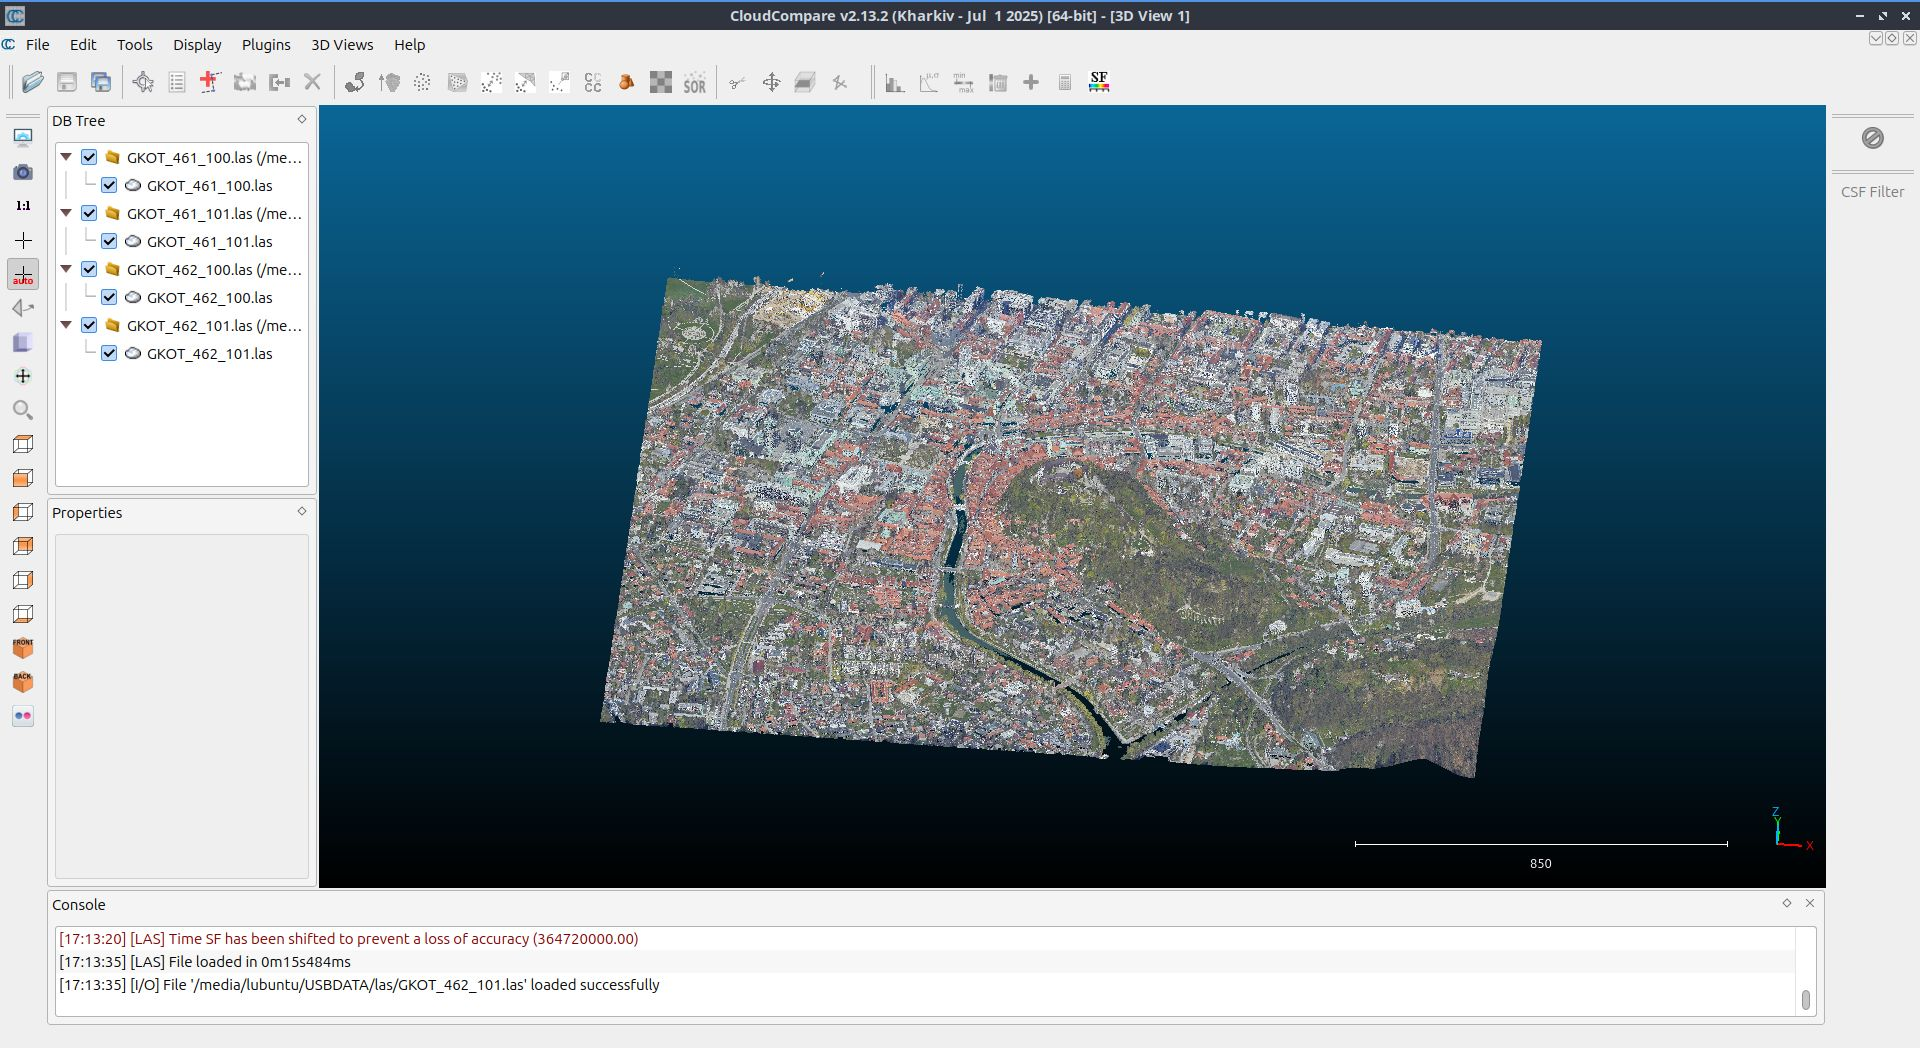

## Let's merge them!

Use the `Edit >  Merge` tool after selecting all loaded point clouds.
All the inputs have the same scalar fields (e.g., Intensity, Classification) so skip the creation of new ones


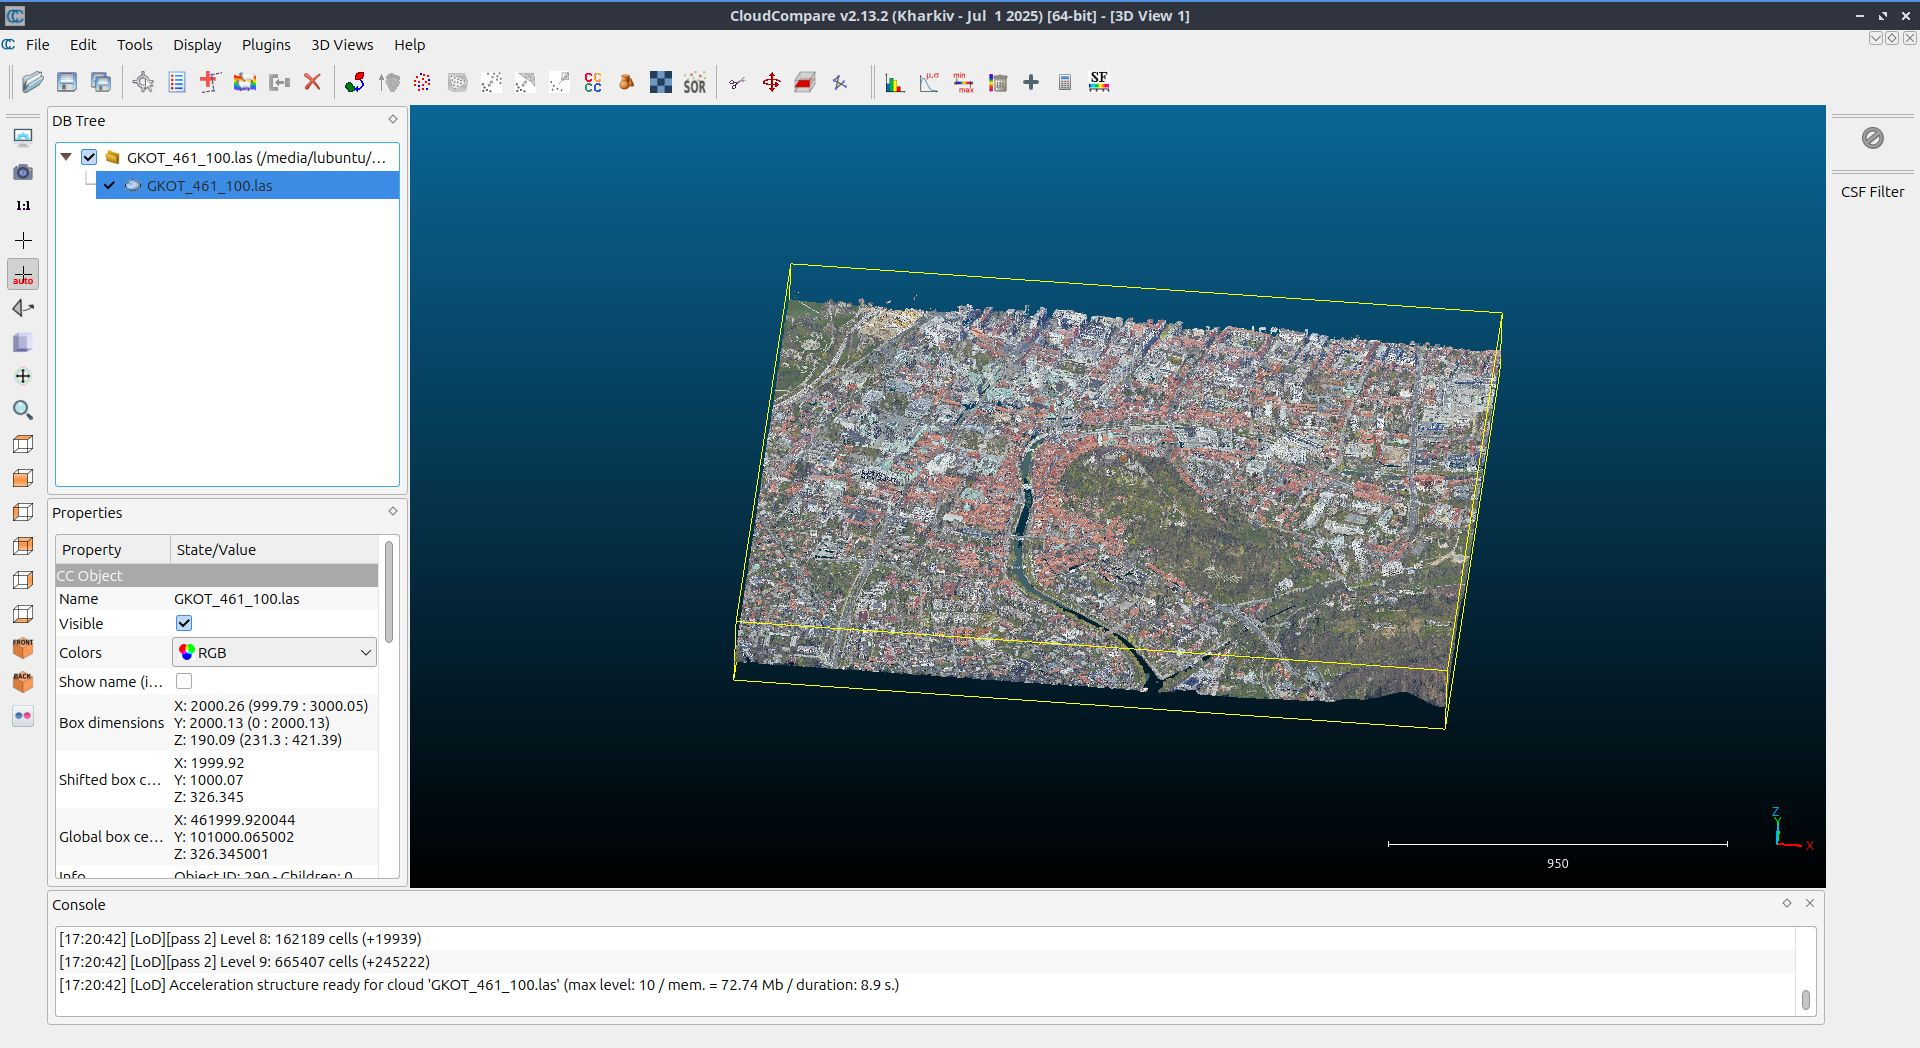

## Let's clip them

Use the `Edit > Segment` tool to trim the dataset to your area of interest.
Click the scissors!




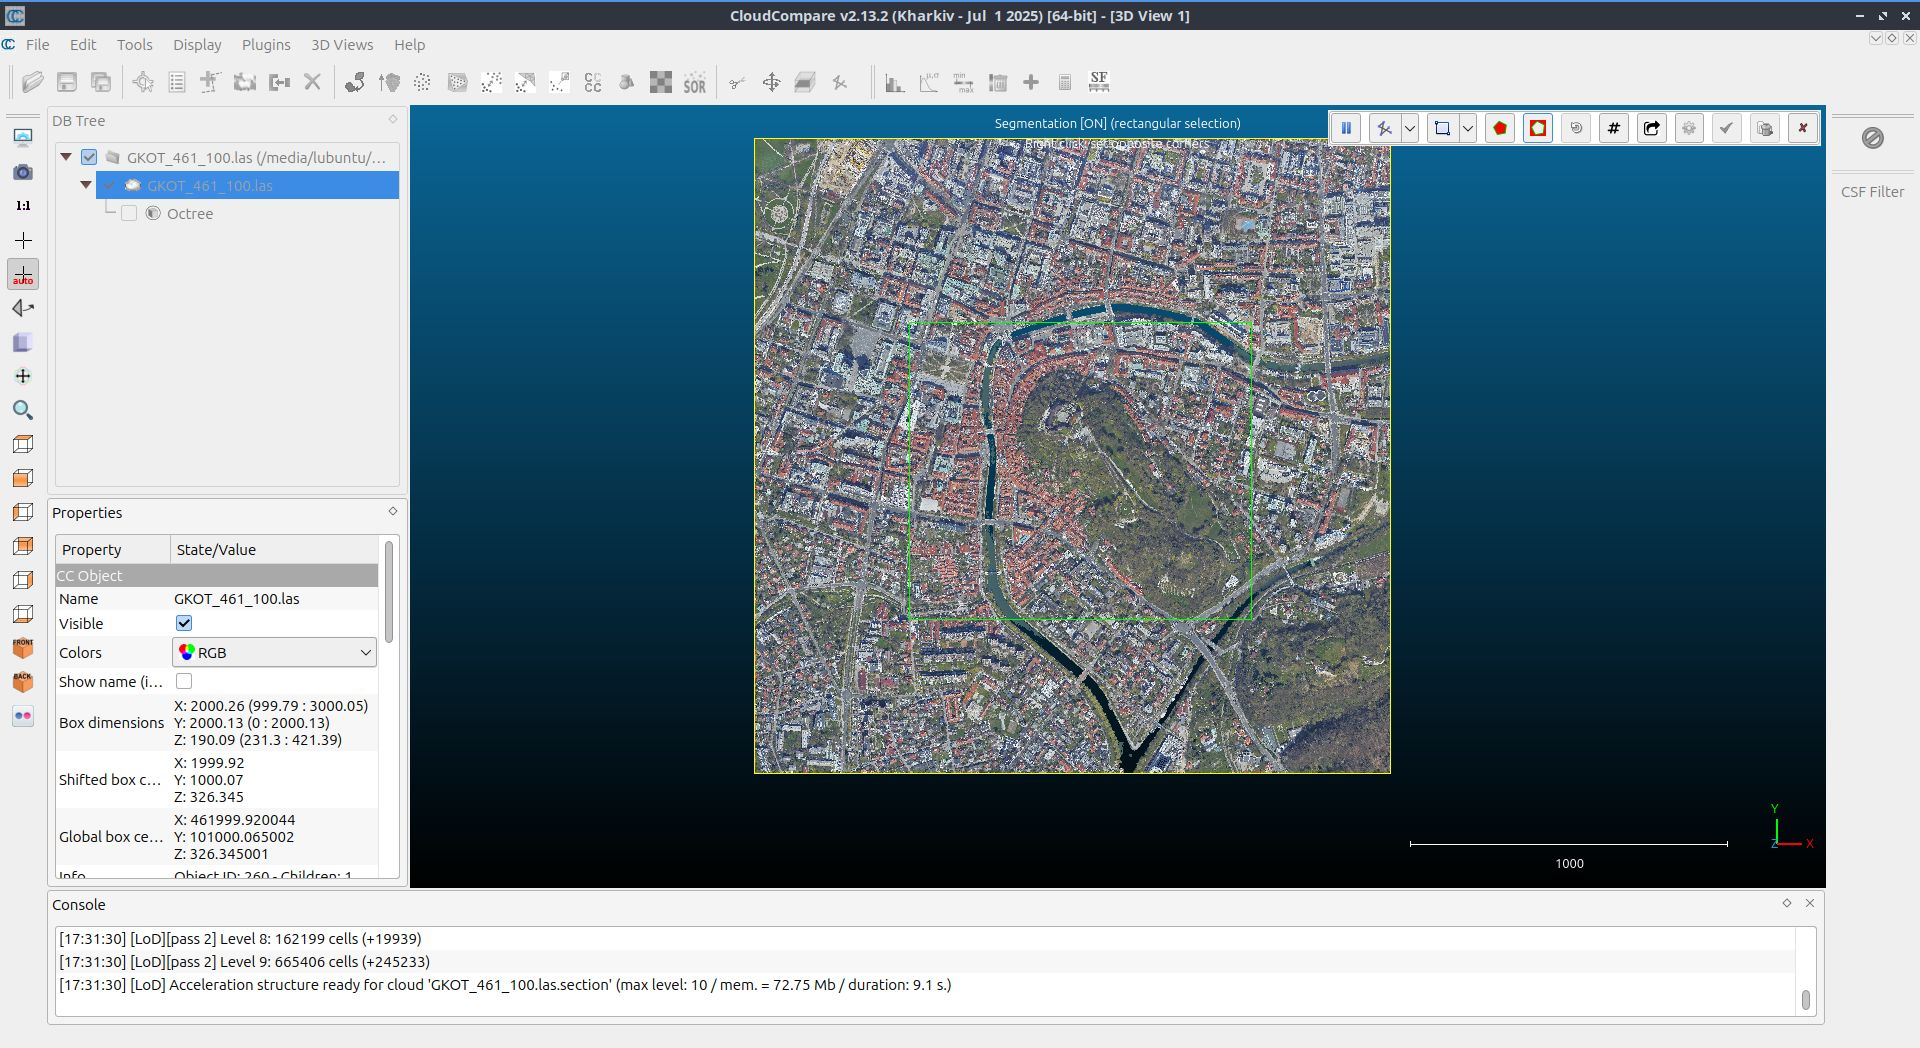

## Let's remove noise

Two primary filters are available for cleaning point clouds:

---

### 1. Statistical Outlier Removal (SOR)

- **Access**: `Tools > Clean > SOR filter`
- **Method**: Computes the average distance of each point to its *k* nearest neighbors. Points that are farther than the average distance plus a multiple of the standard deviation are considered outliers and removed.
- **Parameters**:
  - `k`: Number of nearest neighbors
  - `StdDev multiplier`: Threshold factor
- **Best for**: General noise removal in uniformly distributed point clouds.

---

### 2. Noise Filter

- **Access**: `Tools > Clean > Noise filter`
- **Method**: Fits a local plane around each point and removes points that are too far from this plane. This approach considers the distance to the underlying surface rather than just neighbor distances.
- **Parameters**:
  - `Radius` or `Number of neighbors`: Defines the local neighborhood for plane fitting.
  - `Max error`: Acceptable distance from the fitted plane.
- **Best for**: Cleaning noise from flat surfaces like walls or floors.

---

### Summary

- Use **SOR** for general-purpose noise removal, especially effective for uniformly distributed point clouds.
- Use **Noise Filter** when dealing with flat surfaces or when a more surface-aware approach is needed.

## Let's reclassify the ground points with the CSF filter

Use the **CSF plugin**:  
- Choose appropriate terrain type  
- Adjust slope/cloth resolution if needed  
- Run the filter to extract ground points

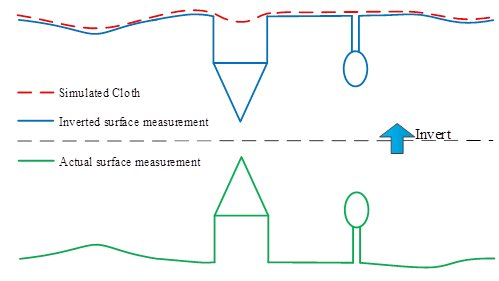

https://www.cloudcompare.org/doc/wiki/index.php/CSF_(plugin)

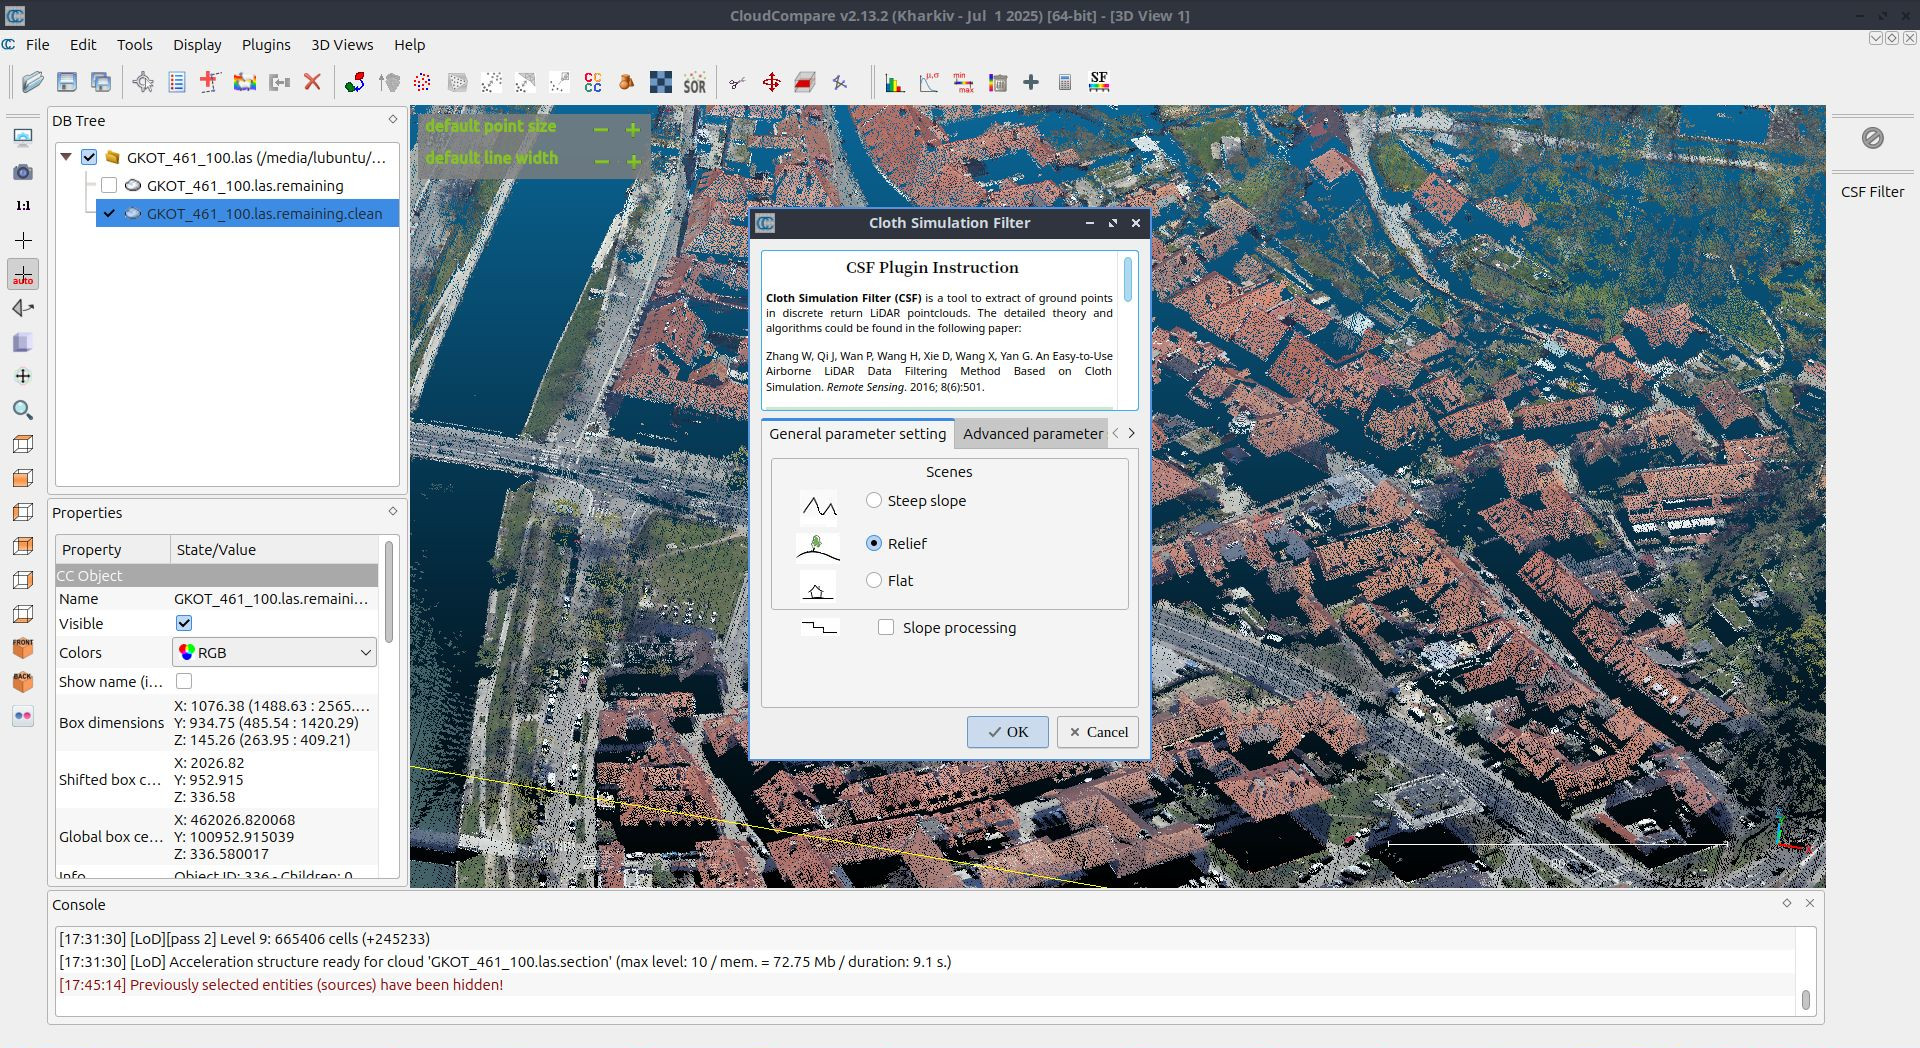

## Creating a 3D Mesh

1. **Compute normals**  
- Normals are vectors that point perpendicular from each surface or point.  
- They help define the "face direction" for rendering, lighting, and surface reconstruction.
`Edit > Normals > Compute`

---


2. **Run Surface Reconstruction**  
- Creates a watertight mesh suitable for visualization and export.
- Try `Plugins > PoisonRecon`
- and `Edit > Mesh > Delaunay 2.5`

---

3. **Simplify**  
- Use `Edit > Mesh > Subsample` to reduce triangle count. Your computer might burn if you skip this.

---

4. **Export as `.PLY`**  
- Compatible with QGIS Mesh Layer. **Do this at home! It is a heavy process!!.**
- In QGIS: **Layer > Add Layer > Add Mesh Layer**

## 2.2 GIS Integration: QGIS
- **QGIS 3.18** introduced native support for point clouds, allowing direct loading of `.LAS`, `.LAZ`, and `.EPT` files.
- **QGIS 3.26** added support for Cloud Optimized Point Cloud (COPC) files, enabling efficient streaming and visualization without the need for indexing.
- **Symbology options** include attribute-based coloring, RGB, classification, and more, enhancing visualization in both 2D and 3D views.
- **QGIS 3.32** expanded point cloud processing capabilities, introducing tools for format conversion, raster export, clipping, and more within the Processing Toolbox.
- **The 3D Map View** allows interactive exploration of point clouds, with features like eye-dome lighting and adjustable point rendering settings.


- **Important to mention:** point clouds were already supported for many years through plugins like LAStools, FUSION and WhiteboxTools.

## Set your CRS settings: we work with Slovenian LiDAR data so let's set this to **EPSG:3794**

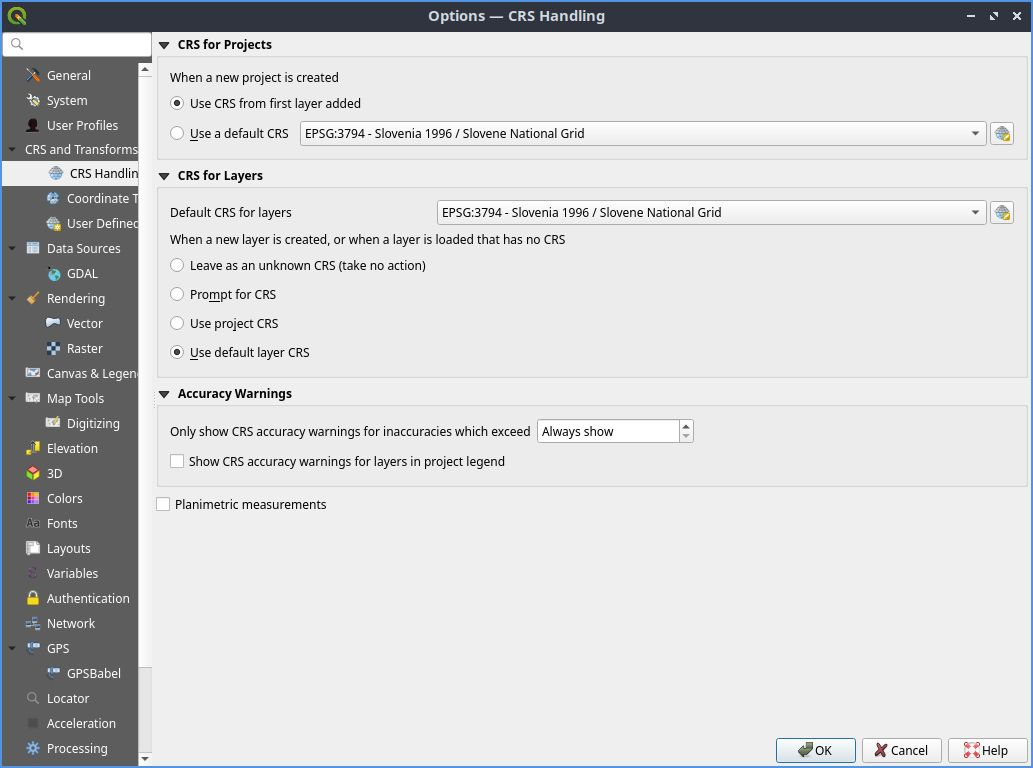


## Open the Processing Toolbox and check the Point Cloud tools avaiable.

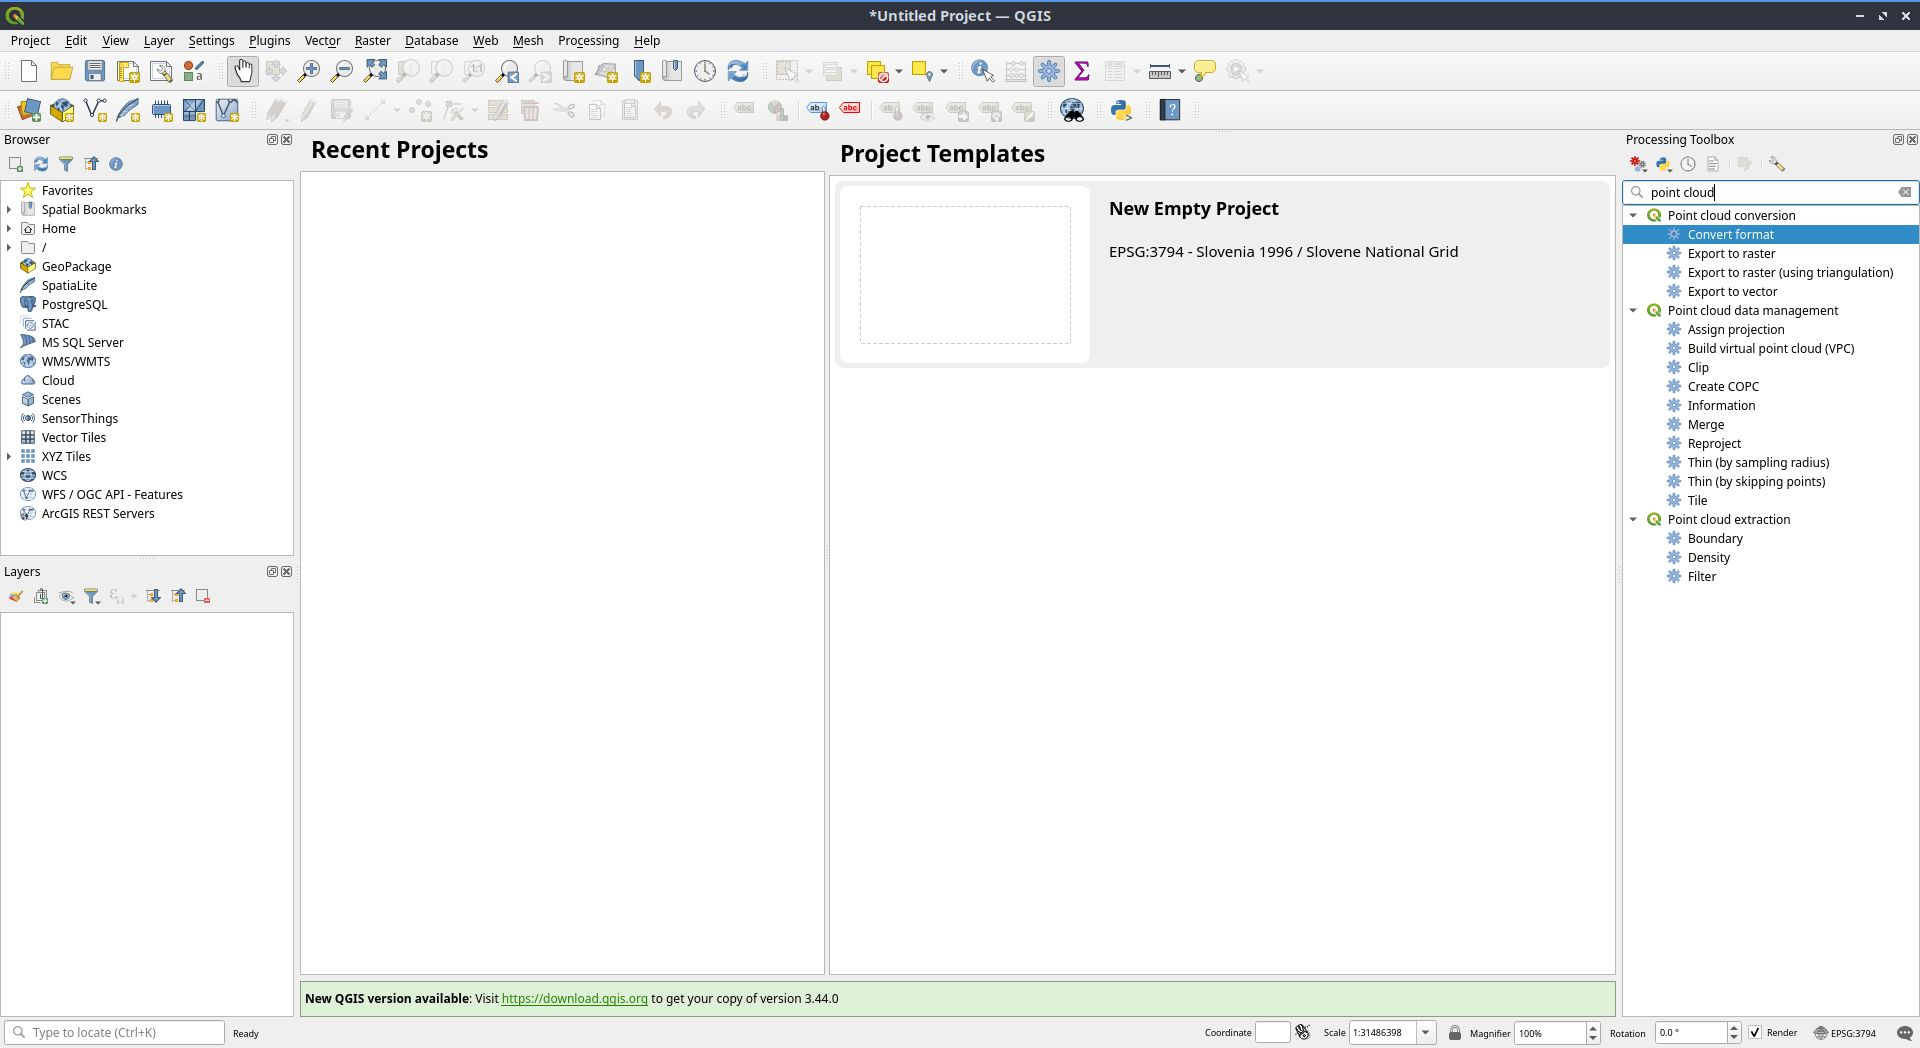

## Creating a DTM and DSM

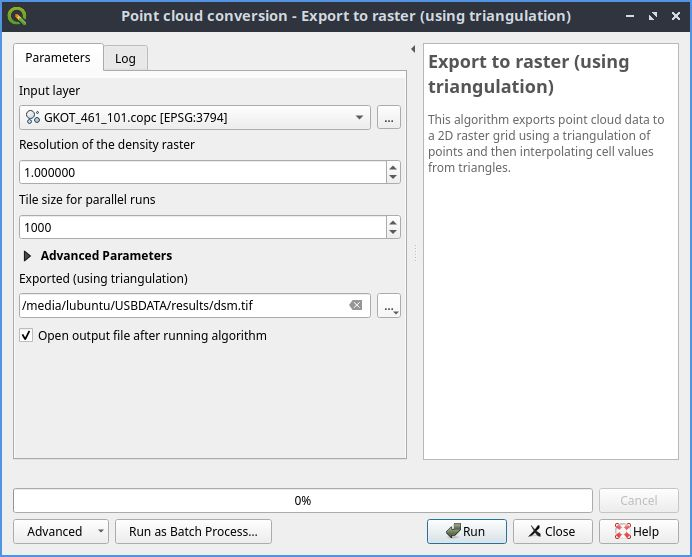


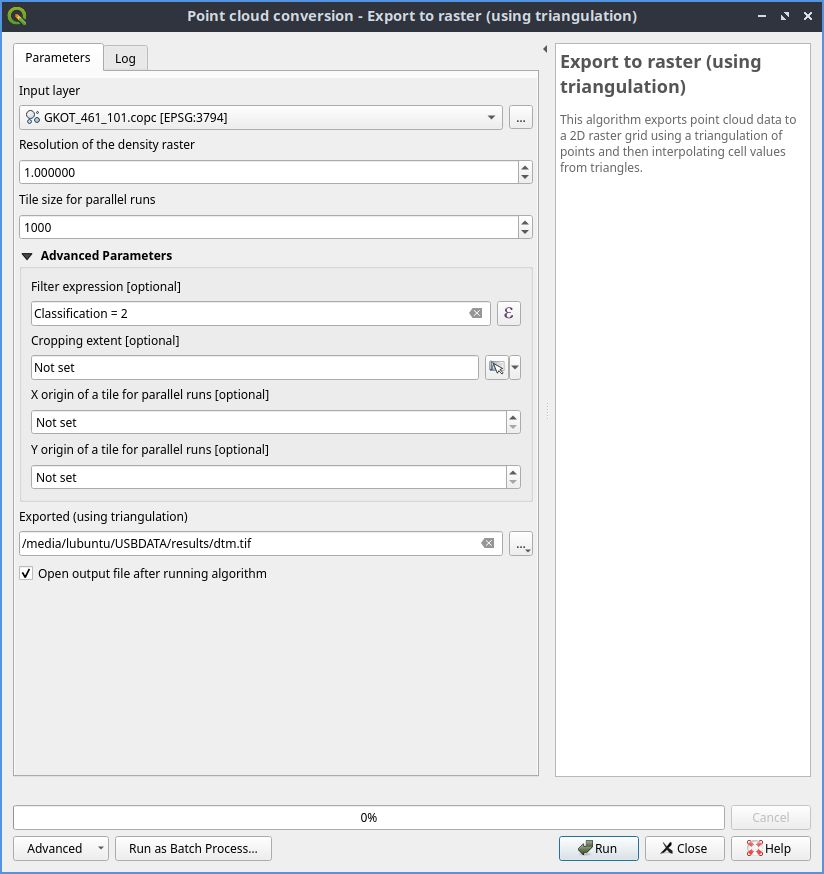

## Virtual Point Clouds

- QGIS virtual point clouds (`.vpc`) link multiple point cloud files without merging them. Similar to `.vrt` for rasters
- They allow fast, scalable visualization and filtering of large datasets.  
- Only visible parts load dynamically—great for performance.  
- Support attribute-based styling (e.g. height, classification).  
- Can be used in 2D and 3D views alongside other GIS layers.

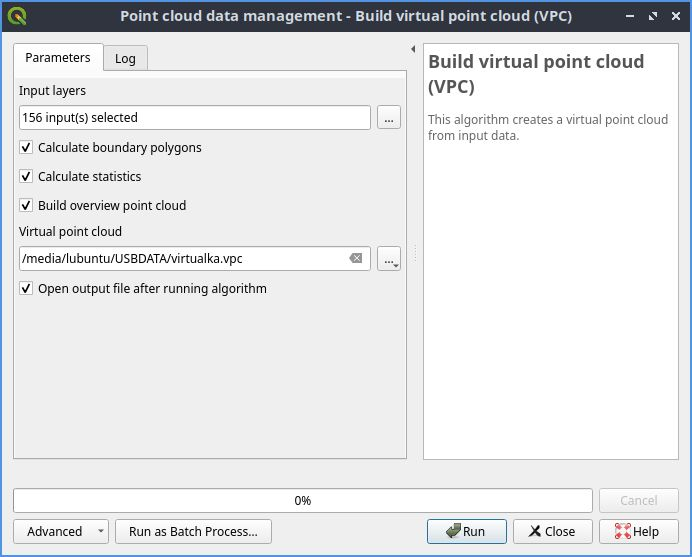

## No need to create one now - check it at home - now let's open an existing one

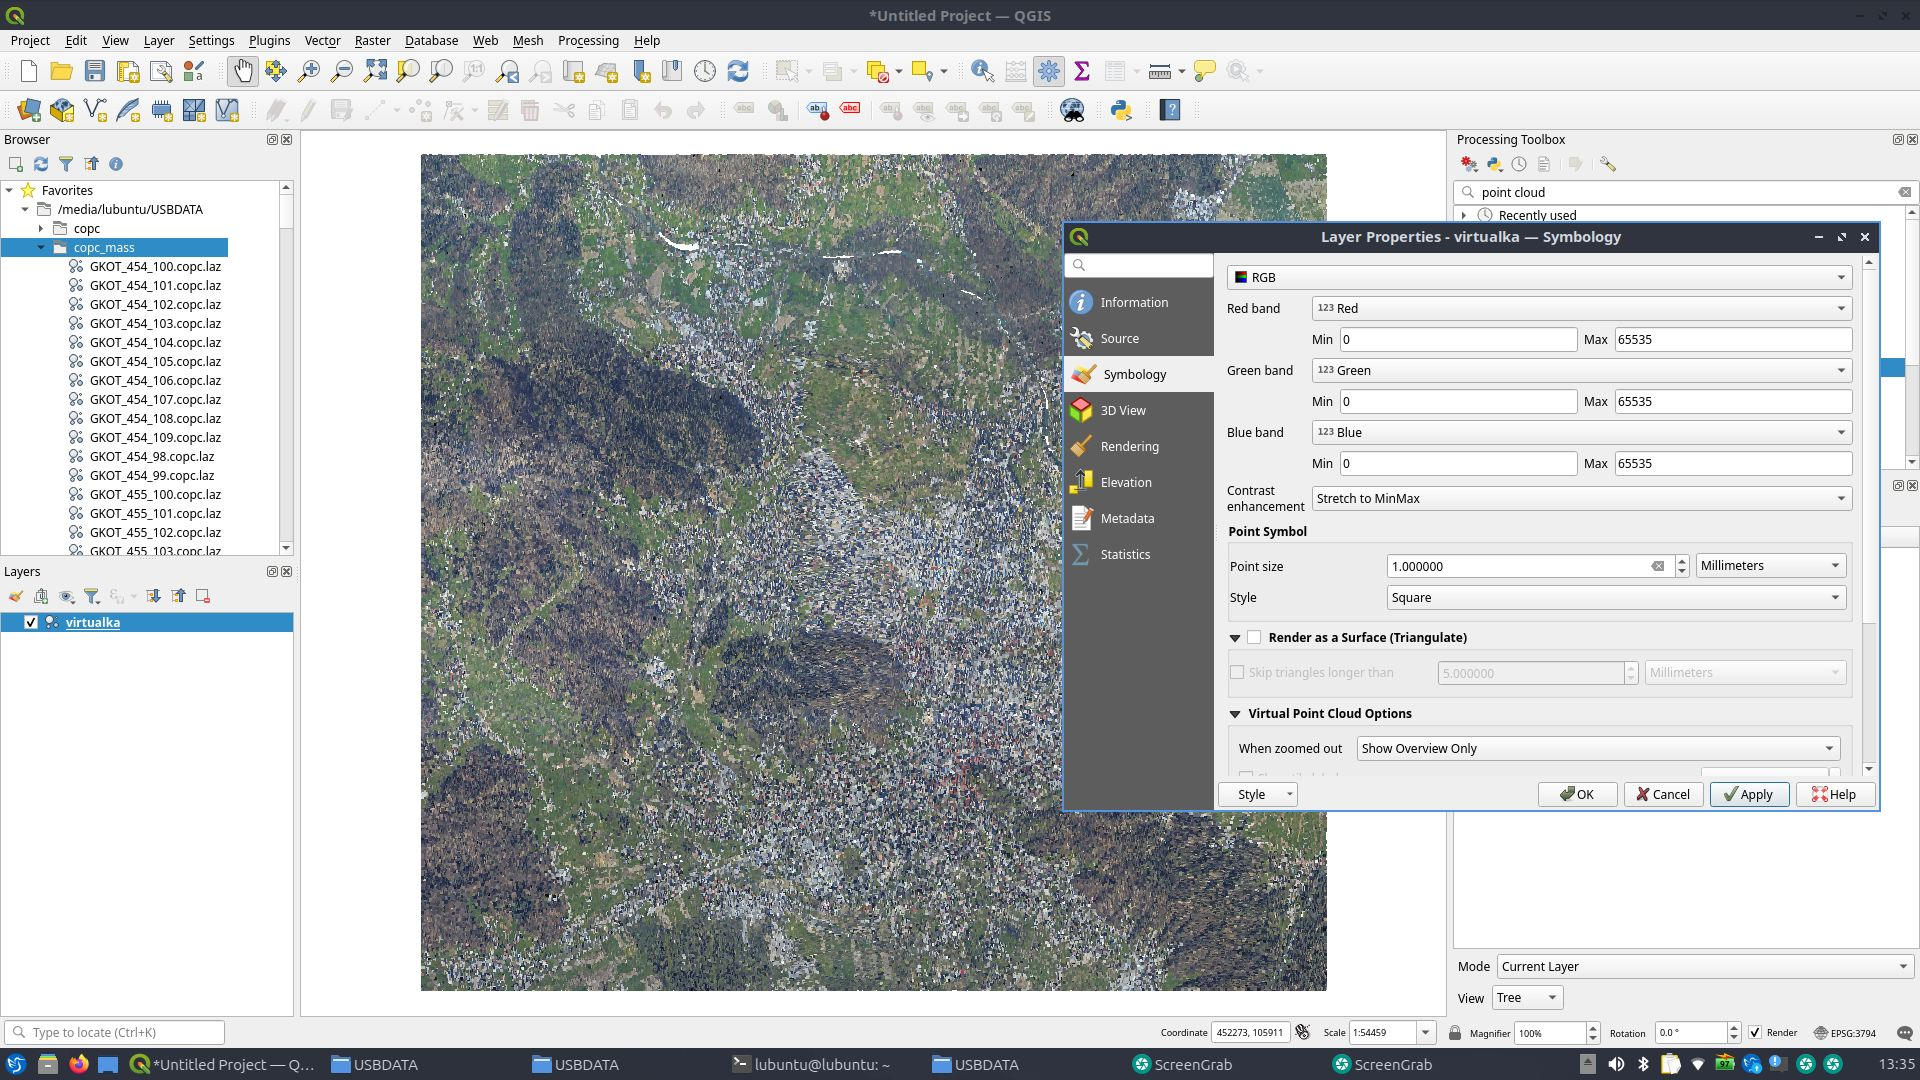


## Open a 3D Map and check it's features

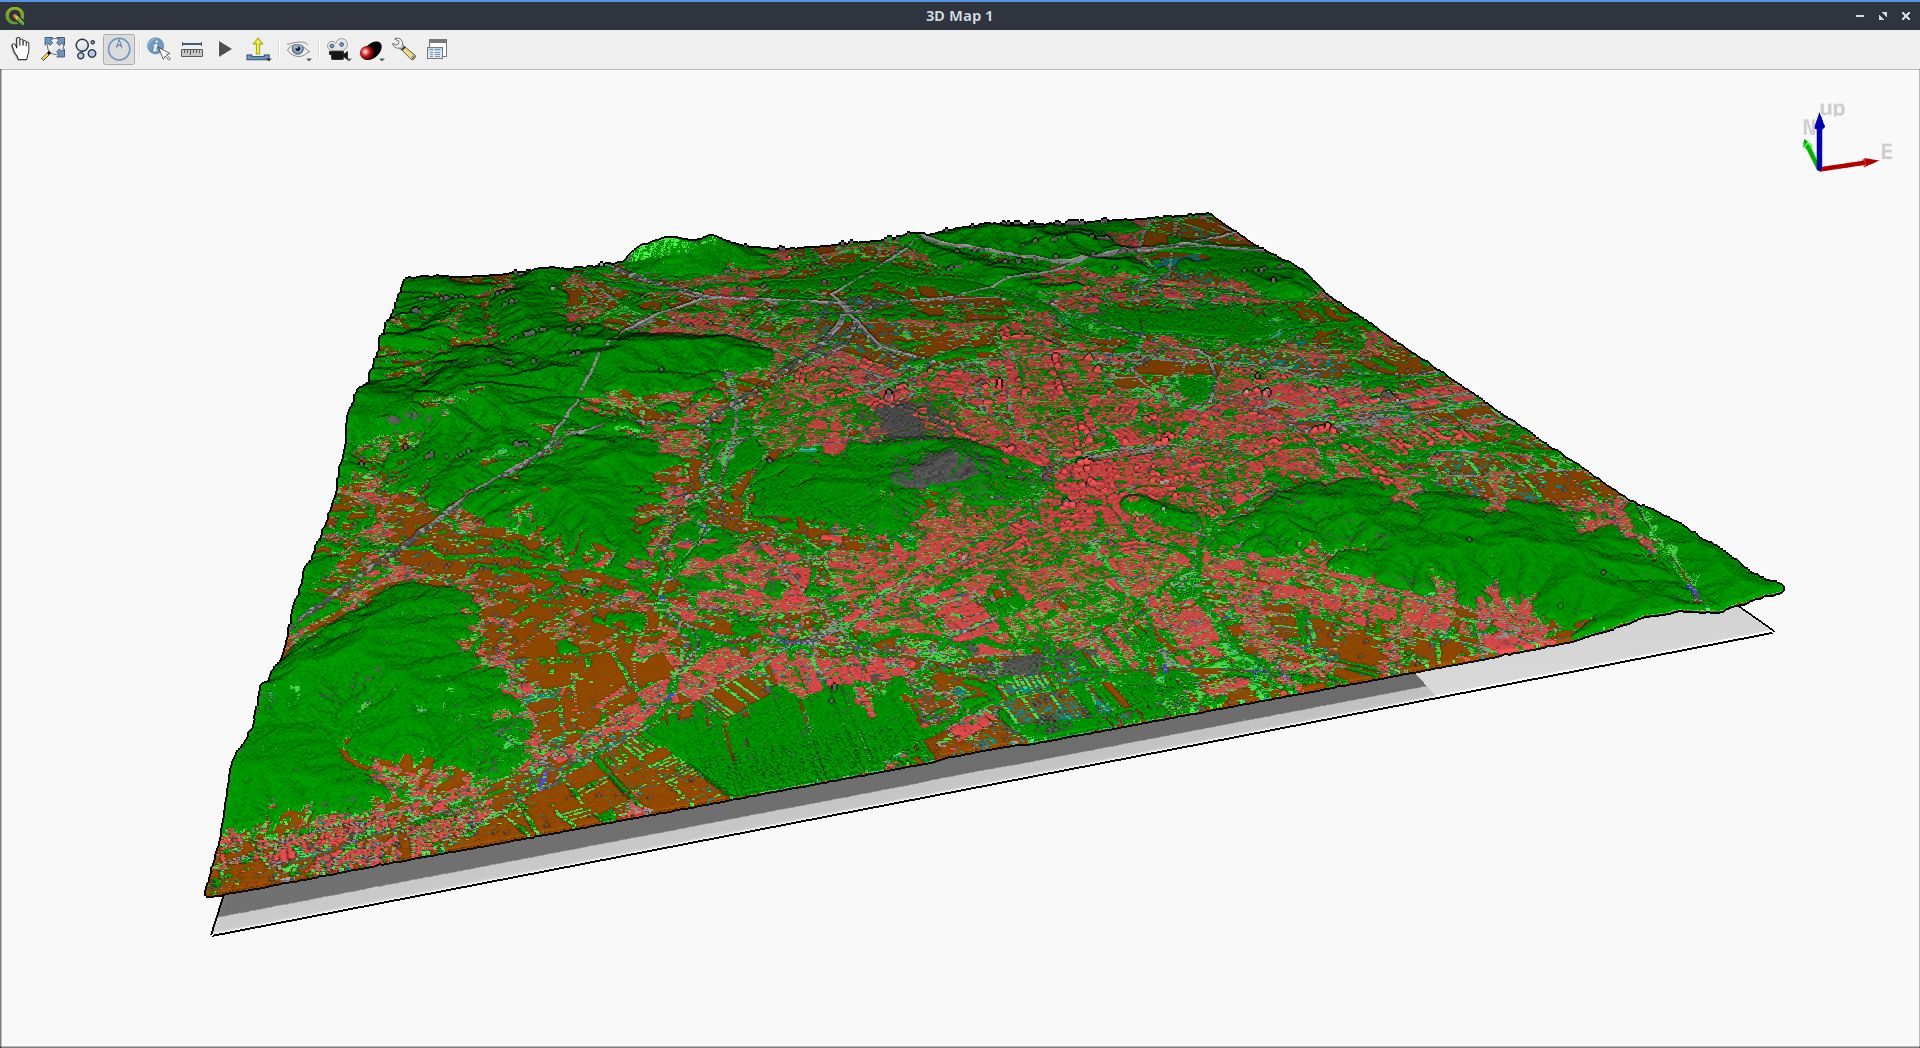

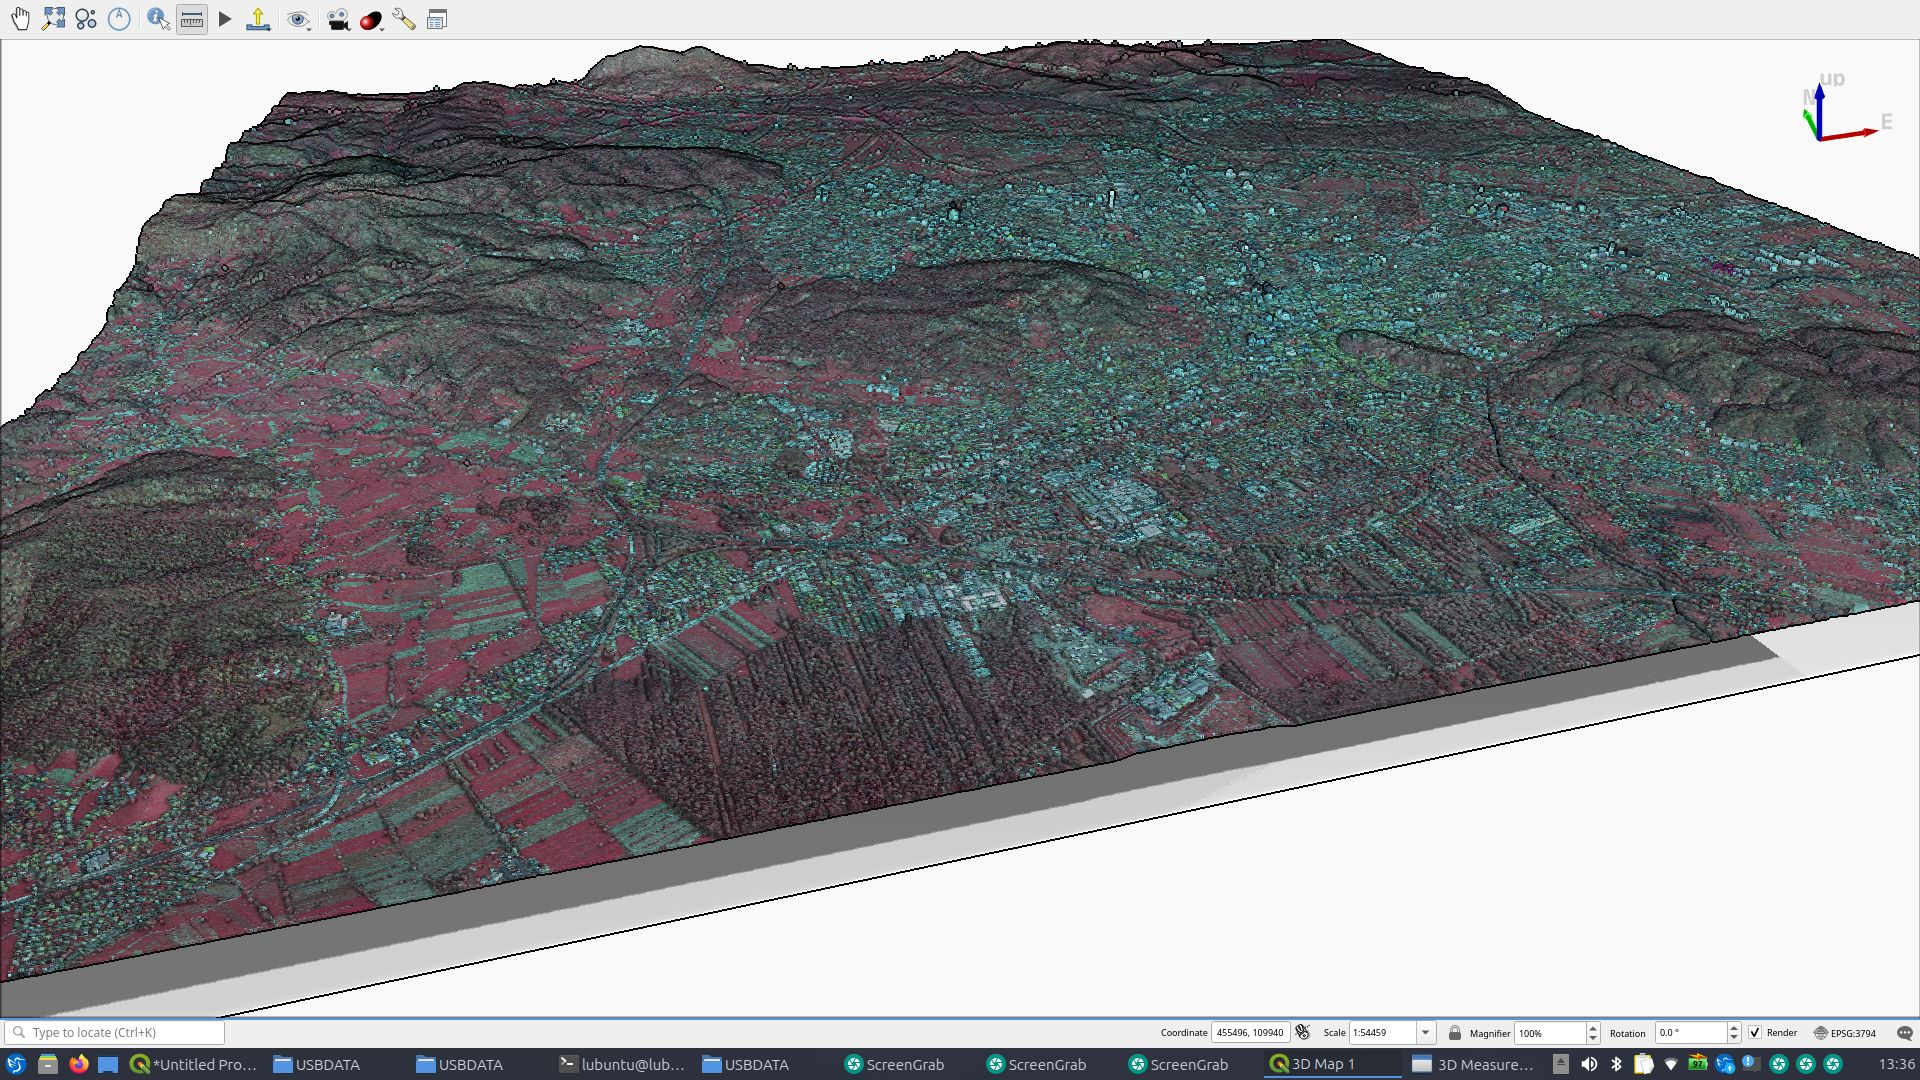

### Open the `Elevation Profile tool` and create a cool section

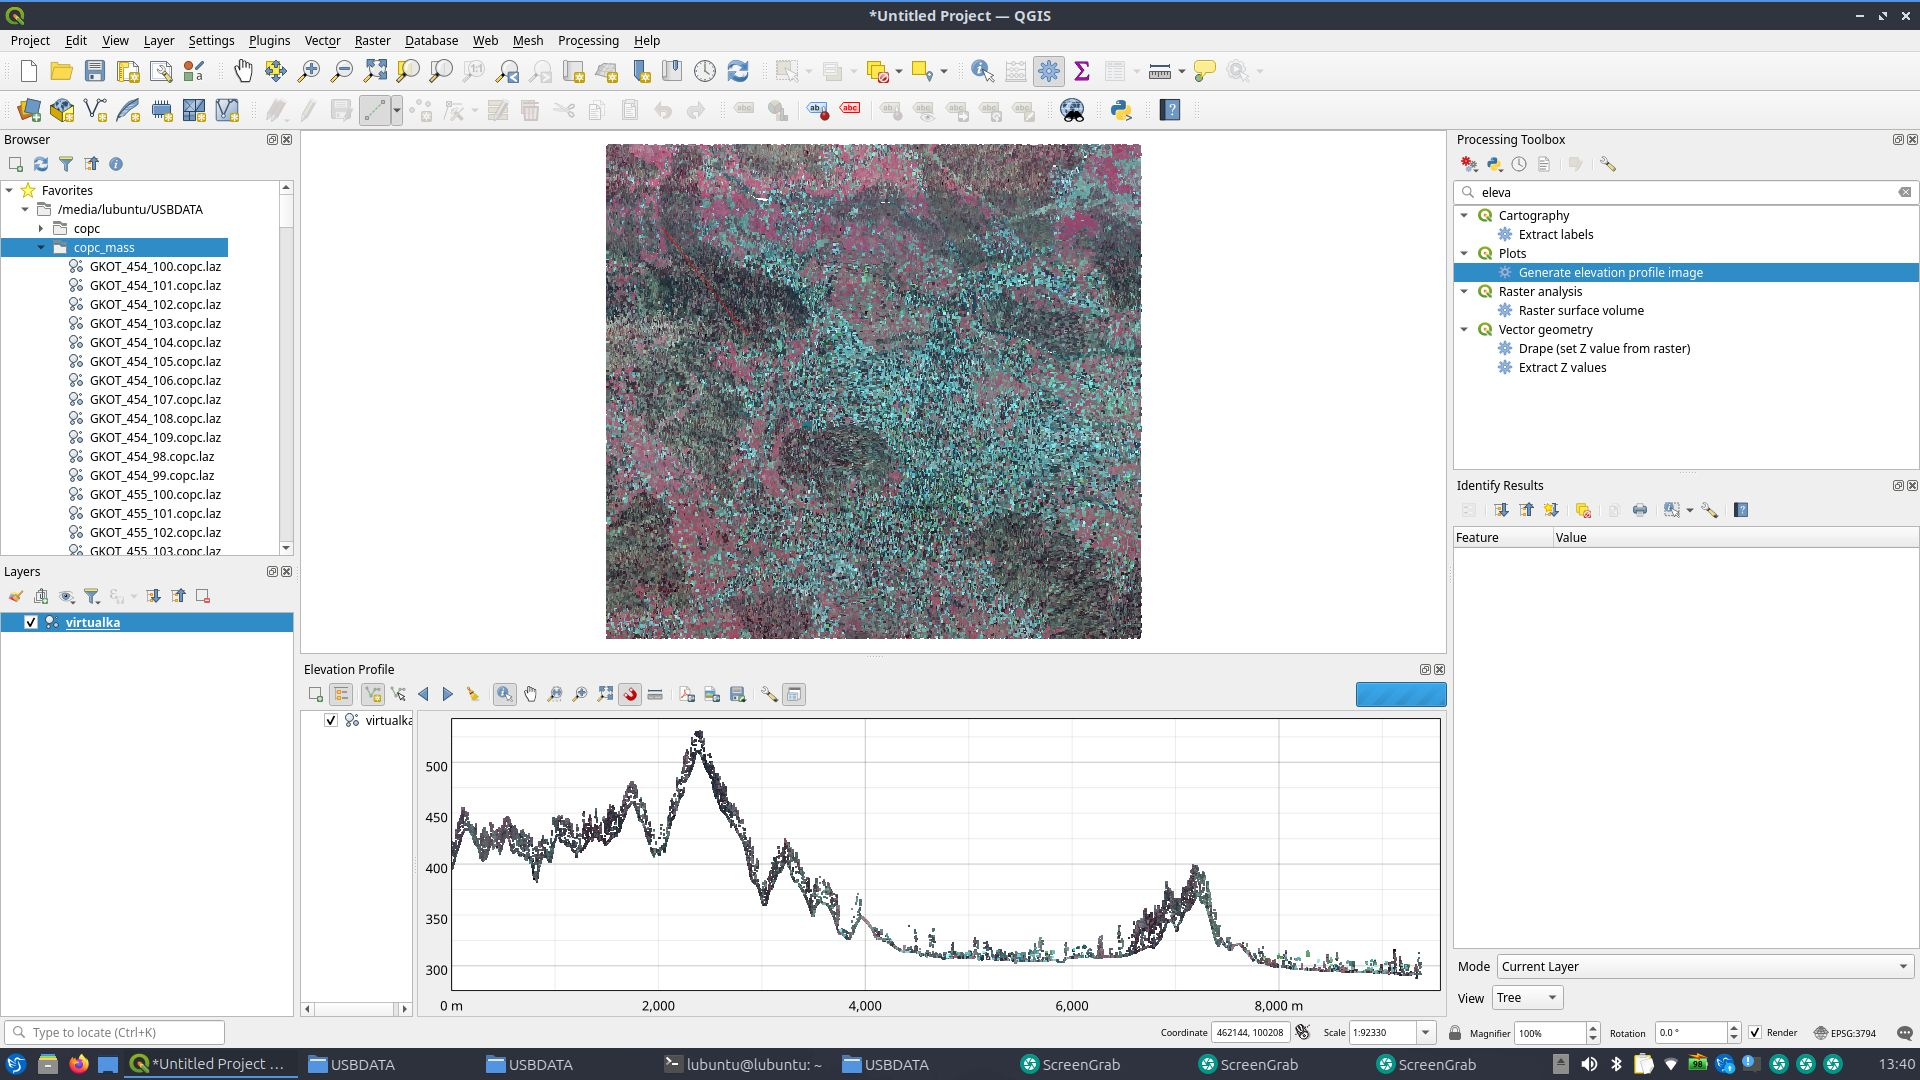

## 3 The PDAL Engine Revealed

### 3.1 PDAL: The Universal Translator

- We created some elevation models and interpolated heights in QGIS – behind that was **PDAL**!
- PDAL (Point Data Abstraction Library) is a powerful backend tool used for reading, filtering, transforming, and writing point cloud data.
- It's like GDAL, but for point clouds.
- QGIS relies on PDAL for many operations like raster generation, clipping, reprojecting, and metadata reading.
- PDAL supports many formats (LAS, LAZ, BPF, E57, etc.) and works well in pipelines for automated processing.
- Command-line basics: info, translate, pipeline

```bash
pdal translate input.laz output.copc.laz --writer copc

### 3.2 Pipeline Power

PDAL pipelines allow you to chain multiple operations: reading, filtering, transforming, and writing in a single structured workflow.

---

#### JSON Structure Dissection

A PDAL pipeline is a JSON array where each element defines a processing stage:

```json
[
  { "type": "readers.las", "filename": "input.laz" },
  { "type": "filters.outlier", "method": "statistical", "mean_k": 20, "multiplier": 2.0 },
  { "type": "filters.csf", "classify": "true" },
  { "type": "filters.range", "limits": "Classification[2:2]" },
  { "type": "writers.gdal", "filename": "dtm.tif", "resolution": 1.0, "output_type": "min" }
]


### Here's an example of a full PDAL pipeline that computes HAG (Height Above Ground) for GKOT_461_101.copc.laz, using ground classification and storing the result:

```json
[
  {
    "type": "readers.las",
    "filename": "GKOT_461_101.copc.laz"
  },
  {
    "type": "filters.hag_delaunay"
  },
  {
    "type": "writers.copc",
    "filename": "GKOT_461_101_hag.copc.laz",
    "a_srs": "EPSG:3794",
    "extra_dims": "HeightAboveGround=float32"
  }
]
  

## This is the way:

```bash
pdal pipeline hag_pipeline.json

## Open it in QGIS and see how cool it is!

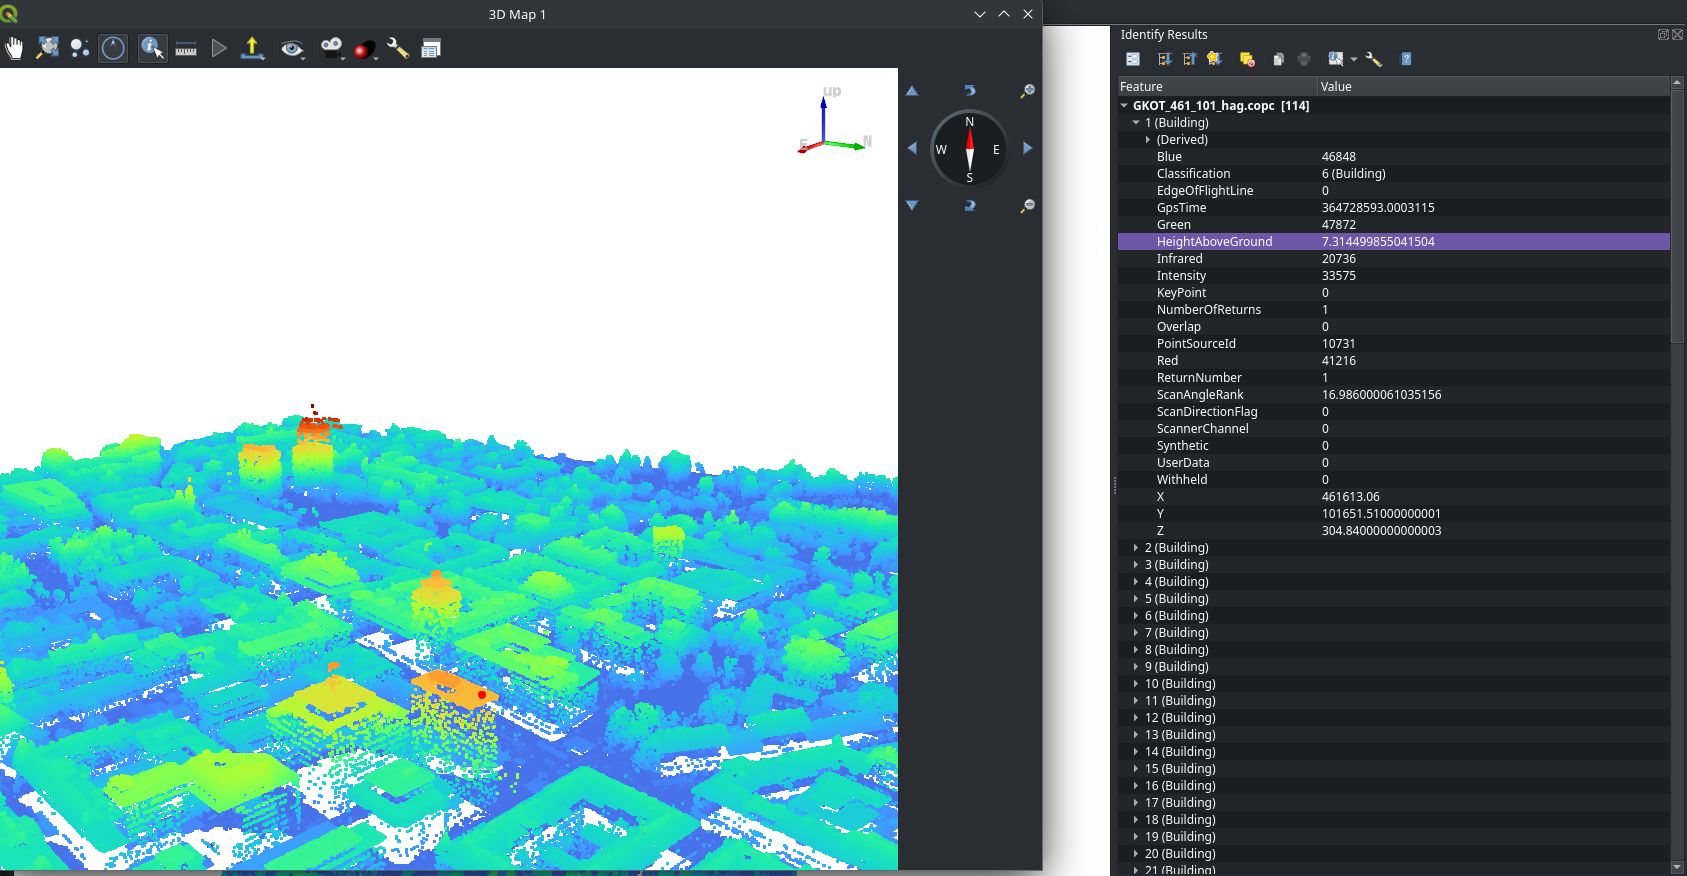

## 4 Python Automation Power Session!
## PDAL, GRASS, Whitebox & Python for End-to-End Workflows


### Convert the source LAZ files to COPC
The workshop data contains ordinary LAZ files. This step converts them to cloud-optimized point clouds under `results/copc/` for the remaining exercises.


In [ ]:
import json
import shutil
import subprocess
import sys
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
from workshop_setup import get_workshop

workshop = get_workshop()
PROJECT_ROOT = workshop.project_root
DATA_DIR = workshop.data_dir
RESULTS_DIR = workshop.results_dir
COPC_DIR = workshop.copc_dir
laz_files = list(workshop.source_laz_files)
if not shutil.which("pdal"):
    raise RuntimeError("PDAL was not found in the selected notebook environment")

def convert_to_copc(laz_path):
    copc_path = COPC_DIR / f"{laz_path.stem}.copc.laz"
    if copc_path.is_file():
        return copc_path
    pipeline = {
        "pipeline": [
            str(laz_path),
            {
                "type": "writers.copc",
                "filename": str(copc_path),
            },
        ]
    }
    subprocess.run(
        ["pdal", "pipeline", "--stdin"],
        input=json.dumps(pipeline),
        text=True,
        check=True,
    )
    return copc_path

with ThreadPoolExecutor(max_workers=len(laz_files)) as executor:
    copc_files = list(executor.map(convert_to_copc, laz_files))

print("COPC files ready:")
for path in copc_files:
    print(f"- {path.name}")


In [ ]:
import tiledb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### Connect to the workshop context
Run this inexpensive helper again after restarting the kernel. It restores paths, GRASS imports, the active session, and `Tools` while reusing results already stored on disk.


In [ ]:
from workshop_setup import get_workshop

workshop = get_workshop()
PROJECT_ROOT = workshop.project_root
DATA_DIR = workshop.data_dir
RESULTS_DIR = workshop.results_dir
COPC_DIR = workshop.copc_dir
gs = workshop.gs
gj = workshop.gj
session = workshop.session
tools = workshop.tools


The context exposes the GRASS modules and active session used below.

In [ ]:
print(f"GRASS project: {workshop.grass_project}")
print(f"GRASS executable: {workshop.grass_executable}")


The `Tools` interface is initialized after opening a GRASS session.

In [ ]:
type(tools)


### Inspect the workshop GRASS project in `results/`


In [ ]:
grass_project = workshop.grass_project
permanent_mapset = workshop.permanent_mapset


The project is reused on later notebook runs so previous workshop results remain available.


In [ ]:
grass_project


### Confirm the active GRASS project and overwrite policy

In [ ]:
print(f"GRASS session: {grass_project}")
print("Overwrite is enabled for all Tools calls.")


### See computational region

In [ ]:
region = tools.g_region(flags="p", format="json").json
region


### Set the resolution

In [ ]:
tools.g_region(res=1)


### Create the input list from the four expected COPC files

In [ ]:
copc_files = [COPC_DIR / f"{path.stem}.copc.laz" for path in laz_files]
missing_copc = [path for path in copc_files if not path.is_file()]
if missing_copc:
    raise FileNotFoundError(f"Missing converted COPC files: {missing_copc}")
copc_list = RESULTS_DIR / "copc.txt"
copc_list.write_text("\n".join(str(path.resolve()) for path in copc_files) + "\n")
copc_list


### Create and import various products with GRASS

> On Windows, `r.in.pdal` is likely to fail during rasterization. In that case, skip the cell below and use the Windows workaround provided afterward. The workaround uses PDAL to create GeoTIFF rasters and then imports them into GRASS with matching extent, resolution, filtering, and aggregation settings.

https://grass.osgeo.org/grass-stable/manuals/r.in.pdal.html

In [ ]:
# With -e we use the extent of the input for the raster extent.
# With -n we set the computation region to match the new raster map.

tools.r_in_pdal(
    file=str(copc_list),
    output="point_cloud_1m",
    resolution=1,
    flags="eno",
)

tools.r_in_pdal(
    file=str(copc_list),
    output="point_cloud_1m_last",
    resolution=1,
    return_filter="last",  # Let's see what points are last.
    flags="eo",
)

tools.r_in_pdal(
    file=str(copc_list),
    output="point_cloud_1m_ground",
    resolution=1,
    class_filter=2,  # Let's see what points are classified as ground.
    flags="eo",
)


#### Windows workaround: Rasterize COPC point clouds with PDAL

In [ ]:
# Windows workaround for r.in.pdal: Rasterize COPC point clouds with PDAL

import math
def pdal_to_geotiff(laz_paths, output_path, resolution=1, expression=None):
    """Rasterize COPC files to a GeoTIFF."""

    # Get the combined extent of the input point clouds and align it to the
    # requested raster resolution.
    #
    # r.in.pdal normally handles this internally when the input extent is used:
    # west/south are rounded down and east/north are rounded up to the raster
    # resolution. Since r.in.pdal rasterization does not work on Windows, we
    # reproduce that grid-alignment step here to keep the resulting region
    # aligned with the one produced by r.in.pdal.
    tile_bounds = [
        json.loads(
            subprocess.run(
                ["pdal", "info", "--summary", str(path)],
                capture_output=True,
                text=True,
                check=True,
            ).stdout
        )["summary"]["bounds"]
        for path in laz_paths
    ]

    west = math.floor(
        min(b["minx"] for b in tile_bounds) / resolution
    ) * resolution

    east = math.ceil(
        max(b["maxx"] for b in tile_bounds) / resolution
    ) * resolution

    south = math.floor(
        min(b["miny"] for b in tile_bounds) / resolution
    ) * resolution

    north = math.ceil(
        max(b["maxy"] for b in tile_bounds) / resolution
    ) * resolution

    width = round((east - west) / resolution)
    height = round((north - south) / resolution)

    ###
    # Build the PDAL pipeline

    # Create tags for the COPC readers so they can be referenced by later
    # pipeline stages.
    reader_tags = [
        f"reader_{index}"
        for index in range(len(laz_paths))
    ]

    pipeline = [
        {
            "type": "readers.copc",
            "filename": str(path),
            "tag": tag,
        }
        for path, tag in zip(laz_paths, reader_tags)
    ]

    # Each reader opens one COPC tile. filters.merge combines the tiles into
    # one point stream before filtering and rasterization. It could be omitted
    # because PDAL stages can accept multiple inputs directly.
    pipeline.append(
        {
            "type": "filters.merge",
            "inputs": reader_tags,
            "tag": "merged",
        }
    )

    writer_input = "merged"

    # Optionally select a subset of points before rasterization.
    if expression:
        pipeline.append(
            {
                "type": "filters.expression",
                "expression": expression,
                "inputs": ["merged"],
                "tag": "filtered",
            }
        )
        writer_input = "filtered"

    pipeline.append(
        {
            "type": "writers.gdal",
            "filename": str(output_path),

            # Raster cell size in the units of the point-cloud CRS.
            "resolution": resolution,

            # Rasterize elevation values.
            "dimension": "Z",

            # Store the mean elevation of points falling into each raster cell.
            "output_type": "mean",

            # Use only points inside each raster cell rather than PDAL's
            # default distance-based neighborhood around the cell center.
            "binmode": True,

            # Store elevation values as 32-bit floating point numbers.
            "data_type": "float",

            # Define the raster grid explicitly using its origin and number of
            # cells. This avoids the extra row and column that writers.gdal
            # creates when using bounds directly and keeps the resulting region
            # aligned with the grid produced by r.in.pdal.
            "origin_x": west,
            "origin_y": south,
            "width": width,
            "height": height,

            "inputs": [writer_input],
        }
    )

    subprocess.run(
        ["pdal", "pipeline", "--stdin"],
        input=json.dumps({"pipeline": pipeline}),
        text=True,
        check=True,
    )


geotiffs = {
    "point_cloud_1m": RESULTS_DIR / "point_cloud_1m.tif",
    "point_cloud_1m_last": RESULTS_DIR / "point_cloud_1m_last.tif",
    "point_cloud_1m_ground": RESULTS_DIR / "point_cloud_1m_ground.tif",
}


# Rasterize all points.
pdal_to_geotiff(
    copc_files,
    geotiffs["point_cloud_1m"],
    resolution=1,
)


# Rasterize last returns.
pdal_to_geotiff(
    copc_files,
    geotiffs["point_cloud_1m_last"],
    resolution=1,

    # This matches the condition used for return_filter="last"
    # in the r.in.pdal source code.
    expression=(
        "(NumberOfReturns > 1) && "
        "(ReturnNumber == NumberOfReturns)"
    ),
)


# Rasterize points classified as ground.
pdal_to_geotiff(
    copc_files,
    geotiffs["point_cloud_1m_ground"],
    resolution=1,

    # LAS classification 2 represents ground points.
    expression="Classification == 2",
)


# Import the generated GeoTIFFs into the active GRASS project.
for raster_name, geotiff in geotiffs.items():
    tools.r_in_gdal(
        input=str(geotiff),
        output=raster_name,
        flags="o",
    )


# Set the computational region from the first raster.
tools.g_region(
    raster="point_cloud_1m",
)


region = tools.g_region(
    flags="p",
    format="json",
).json

region

### Create a list of the rasters we produced

In [ ]:
point_cloud_check = [
    "point_cloud_1m",
    "point_cloud_1m_last",
    "point_cloud_1m_ground",
]
available_rasters = {
    item["name"]
    for item in tools.g_list(type="raster", format="json").json
}
missing_rasters = set(point_cloud_check) - available_rasters
if missing_rasters:
    raise RuntimeError(f"GRASS rasters were not created: {sorted(missing_rasters)}")
point_cloud_check


### Visualize the products as 2D

In [ ]:
from workshop_setup import get_workshop

workshop = get_workshop()
gj = workshop.gj
tools = workshop.tools
RESULTS_DIR = workshop.results_dir
point_cloud_check = [
    "point_cloud_1m", "point_cloud_1m_last", "point_cloud_1m_ground"
]
series = gj.SeriesMap(height=700)
series.add_rasters(point_cloud_check)
series.d_grid(size=250, color="orange")
series.show()


In [ ]:
series.save(RESULTS_DIR / "image.gif")  # Export it into a GIF for a presentation.


### Let's interpolate the ground points and crate a nice DTM

### Check the one-metre computational region used by the interpolation

In [ ]:
region = tools.g_region(flags="p", format="json").json
region


In [ ]:
from workshop_setup import get_workshop

workshop = get_workshop()
RESULTS_DIR = workshop.results_dir
gj = workshop.gj
tools = workshop.tools

tools.r_fill_stats(
    input="point_cloud_1m_ground",
    output="point_cloud_1m_ground_idw",
    distance=11,
    flags="k",
)


In [ ]:
m = gj.InteractiveMap(width=700, height=700, tiles=None)
m.add_raster('point_cloud_1m_ground_idw')
m.add_layer_control()
m.show()

In [ ]:
# Awesome, but heavy: try it at home and compare the results.
# tools.r_resamp_bspline(
#     input="point_cloud_1m_ground_idw",
#     output="dtm",
#     method="bilinear",
#     memory=2000,
# )


In [ ]:
tools.r_relief(
    input="point_cloud_1m_ground_idw",
    output="point_cloud_1m_ground_idw_hs",
    altitude=30,
    azimuth=315,
)


In [ ]:
m = gj.InteractiveMap(width=700, height=700, tiles=None)
m.add_raster('point_cloud_1m_ground_idw_hs')
m.add_layer_control()
m.show()

### Lets's export it as GeoTIFF

In [ ]:
tools.r_out_gdal(
    input="point_cloud_1m_ground_idw",
    output=str(RESULTS_DIR / "point_cloud_1m_ground_idw.tif"),
    format="GTiff",
    createopt="COMPRESS=DEFLATE,PREDICTOR=3",
)


### Feature Engineering with GRASS, NumPy, and scikit-image
We move the interpolated elevation raster into NumPy and derive entropy and edge-strength rasters. These are engineered features: useful transformations for later analysis, not a machine-learning model.

In [ ]:
import numpy as np

from workshop_setup import get_workshop

workshop = get_workshop()
tools = workshop.tools
import grass.script.array as garray
dtm_narray = garray.array('point_cloud_1m_ground_idw')

In [ ]:
dtm_max = np.nanmax(dtm_narray)
print(dtm_max)


In [ ]:
from skimage.filters import sobel
from skimage.filters.rank import entropy
from skimage.morphology import disk
from skimage.util import img_as_ubyte

# Normalize valid DTM values to 0-1.
dtm_min = np.nanmin(dtm_narray)
dtm_max = np.nanmax(dtm_narray)
if dtm_max == dtm_min:
    raise ValueError("The DTM has no elevation range")
dtm_norm = (dtm_narray - dtm_min) / (dtm_max - dtm_min)
dtm_norm = np.nan_to_num(dtm_norm, nan=0.0)

# Convert to 8-bit image
dtm_byte = img_as_ubyte(dtm_norm)

# Apply entropy
entropy_map = entropy(dtm_byte, disk(3))

# Sobel works on the normalized floating-point image.
edges = sobel(dtm_norm)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(entropy_map, cmap='gray')
axes[0].set_title('Entropy')
axes[0].axis('off')

axes[1].imshow(edges, cmap='viridis')
axes[1].set_title('Edges (Sobel)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Store Engineered Features Back in GRASS
The derived arrays can be stored as GRASS rasters and reused by later spatial workflows or models.

In [ ]:
entropy_grass = garray.array()
entropy_grass[...] = entropy_map
entropy_grass.write("entropy_map", overwrite=True)

edges_grass = garray.array()
edges_grass[...] = edges
edges_grass.write("edges", overwrite=True)


## Point-Cloud Inspection with WhiteboxTools

https://www.whiteboxgeo.com/manual/wbt_book/available_tools/lidar_tools.html

In [ ]:
import whitebox
from workshop_setup import get_workshop

workshop = get_workshop()
RESULTS_DIR = workshop.results_dir
COPC_DIR = workshop.copc_dir
wbt = whitebox.WhiteboxTools()


In [ ]:
input_file = COPC_DIR / "GKOT_461_100.copc.laz"
output = RESULTS_DIR / f"{input_file.stem}.html"

wbt.lidar_info(
    str(input_file),
    str(output),
    vlr=True,
    geokeys=True,
)


### Now check the report. **How much water is there?** Open the COPC in QGIS as well, lets have a debate.

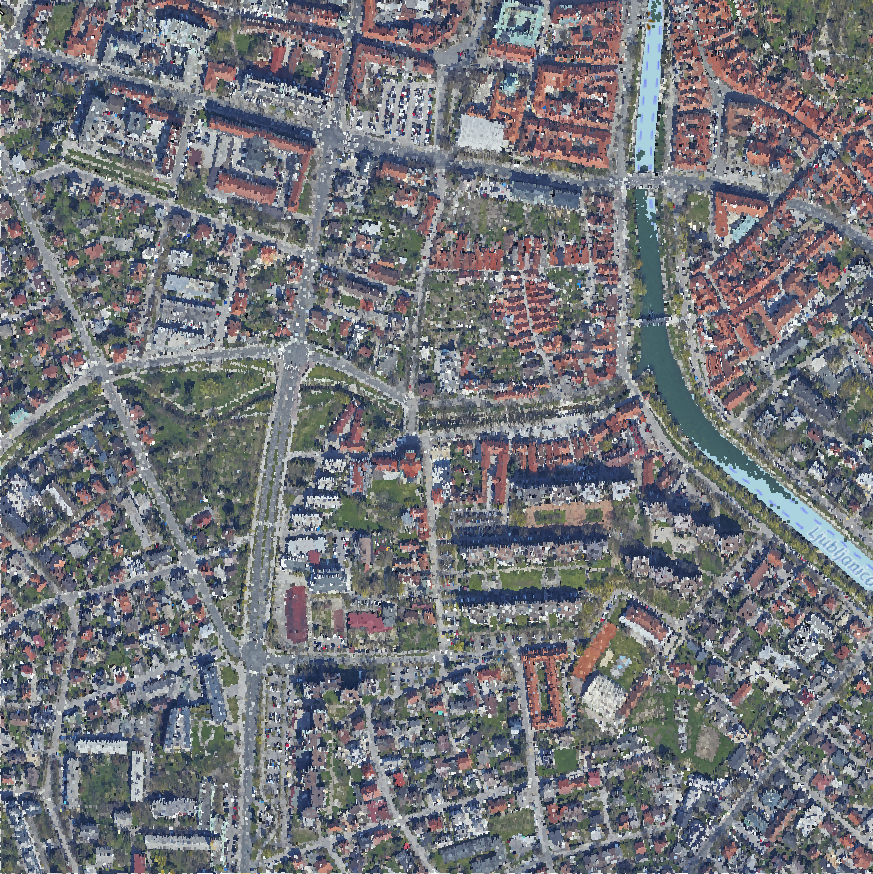

### Object Segmentation from Classified Building Points
This is image segmentation with watershed, not machine learning: PDAL selects known class-6 building points and scikit-image separates connected objects.

In [ ]:
import json
import subprocess
from workshop_setup import get_workshop

workshop = get_workshop()
RESULTS_DIR = workshop.results_dir
COPC_DIR = workshop.copc_dir
laz_file = COPC_DIR / "GKOT_461_100.copc.laz"
out_raster = RESULTS_DIR / "buildings_mask.tif"
pipeline_file = RESULTS_DIR / f"{laz_file.stem}_raster_pipeline.json"
if out_raster.exists():
    out_raster.unlink()

pipeline = {
    "pipeline": [
        {
            "type": "readers.copc",
            "filename": str(laz_file),
        },
        {
            "type": "filters.range",
            "limits": "Classification[6:6]",
        },
        {
            "type": "writers.gdal",
            "filename": str(out_raster),
            "resolution": 1.0,
            "output_type": "count",
            "data_type": "uint16",
            "nodata": 0,
        },
    ]
}

pipeline_file.write_text(json.dumps(pipeline, indent=2))
subprocess.run(["pdal", "pipeline", str(pipeline_file)], check=True)


### Open the results in QGIS and lets debate about it.

In [ ]:
import tifffile as tiff
from skimage.morphology import erosion, rectangle

mask_path = RESULTS_DIR / "buildings_mask.tif"
data = tiff.imread(mask_path)

binary = (data > 0).astype(np.uint8)
eroded = erosion(binary, rectangle(3, 3))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(binary, cmap="gray")
ax[0].set_title("Original mask")
ax[0].axis("off")
ax[1].imshow(eroded, cmap="gray")
ax[1].set_title("Eroded mask")
ax[1].axis("off")
plt.tight_layout()
plt.show()


In [ ]:
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.measure import regionprops

# Distance transform and local maxima from eroded mask
distance = ndi.distance_transform_edt(eroded)
coords = peak_local_max(distance, labels=eroded, min_distance=20)

# Marker image
markers = np.zeros_like(eroded, dtype=np.int32)
for i, (r, c) in enumerate(coords, 1):
    markers[r, c] = i

# Watershed segmentation
labels_ws = watershed(-distance, markers, mask=eroded)

# Keep regions of at least 100 pixels (100 square metres at 1 m resolution).
filtered = np.zeros_like(labels_ws, dtype=np.int32)
retained_regions = [region for region in regionprops(labels_ws) if region.area >= 100]
for new_label, region in enumerate(retained_regions, 1):
    filtered[labels_ws == region.label] = new_label

# Count and plot
n_buildings = len(retained_regions)
plt.figure(figsize=(12, 10))
plt.imshow(filtered, cmap="nipy_spectral")
plt.title(f"Watershed segmentation — {n_buildings} buildings")
plt.axis("off")
plt.tight_layout()
plt.show()


## Scalable Point-Cloud Analysis with TileDB

### Store the Complete Point Cloud in TileDB

In [ ]:
import json
import shutil
import subprocess
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tiledb
from workshop_setup import get_workshop

workshop = get_workshop()
RESULTS_DIR = workshop.results_dir
COPC_DIR = workshop.copc_dir
tile_copcs = list(workshop.copc_files)
array_name = RESULTS_DIR / "tiledb_pc"


Let's create one TileDB array containing all four workshop COPCs: **78,587,620 points**. The files are written sequentially, so the import remains suitable for laptops and does not merge all points in memory.

In [ ]:
if array_name.exists():
    shutil.rmtree(array_name)

import_started = time.perf_counter()
for index, tile_copc in enumerate(tile_copcs):
    pipeline = {
        "pipeline": [
            {"type": "readers.copc", "filename": str(tile_copc)},
            {
                "type": "writers.tiledb",
                "filename": str(array_name),
                "append": index > 0,
                "x_tile_size": 100,
                "y_tile_size": 100,
                "z_tile_size": 100,
            },
        ]
    }
    subprocess.run(
        ["pdal", "pipeline", "--stdin"],
        input=json.dumps(pipeline),
        text=True,
        check=True,
    )
    print(f"Imported {index + 1}/{len(tile_copcs)}: {tile_copc.name}")

print(f"TileDB import completed in {time.perf_counter() - import_started:.1f} s")


### Explore Point Classes

### Inspect the TileDB Schema and Occupied Extent
The schema domain describes the allowed coordinate range. `nonempty_domain()` reports the actual minimum and maximum coordinates occupied by this point cloud, which is what we use to choose a smaller area manually.

In [ ]:
scan_started = time.perf_counter()
with tiledb.open(str(array_name), "r") as array:
    classifications = array.query(
        attrs=["Classification"], coords=False
    )[:]["Classification"]
if classifications.size == 0:
    raise RuntimeError("The TileDB array contains no points")

print(
    f"Scanned {len(classifications):,} classifications in "
    f"{time.perf_counter() - scan_started:.2f} s"
)
vals, counts = np.unique(classifications, return_counts=True)
del classifications
df = pd.DataFrame({"Classification": vals, "Count": counts})
df = df.sort_values("Count", ascending=False).reset_index(drop=True)

# Plot the histogram.
plt.figure(figsize=(8, 5))
plt.bar(df["Classification"].astype(str), df["Count"])
plt.xlabel("Classification")
plt.ylabel("Count")
plt.title("Histogram of Classification")
plt.tight_layout()
plt.show()


In [ ]:
with tiledb.open(str(array_name)) as array:
    tiledb_schema = array.schema
    tiledb_extent = array.nonempty_domain()

print(tiledb_schema.domain)
print("Occupied X, Y, Z extent:", tiledb_extent)


### Visualize the Original TileDB Area in Natural Color
Before changing areas, we keep the original RGB view of `GKOT_461_100` as our first TileDB visualization. The browser display is capped at 100,000 points.

In [ ]:
from pybabylonjs import Show as show

original_window = {
    "x": (461150, 461250),
    "y": (100300, 100400),
    "z": (274, 300),
}
with tiledb.open(str(array_name)) as array:
    original_points = array.query(
        attrs=("Red", "Green", "Blue"), coords=True
    ).multi_index[
        original_window["x"][0]:original_window["x"][1],
        original_window["y"][0]:original_window["y"][1],
        original_window["z"][0]:original_window["z"][1],
    ]
display_rng = np.random.default_rng(42)
original_display = display_rng.choice(
    len(original_points["X"]),
    size=min(100_000, len(original_points["X"])),
    replace=False,
)
original_point_data = {
    name: values[original_display] for name, values in original_points.items()
}
show.point_cloud(
    source="dict", data=original_point_data, point_size=4, rgb_max=65535,
    width=1200, height=700
)


### Choose a New 100 × 100 m Analysis Window
We now move north into `GKOT_461_101`. The rounded bounds contain the earlier example point at X 461076.61, Y 101763.8. X/Y are reused for ML inference and the probability raster; Z limits only the 3D views.

In [ ]:
analysis_window = {
    "x": (461000, 461100),
    "y": (101700, 101800),
    "z": (298, 327),
}
analysis_window


### Visualize the New Analysis Area in Natural Color
We inspect the new area before modeling it. This provides the visual reference for the probability raster and model-colored 3D result.

In [ ]:
with tiledb.open(str(array_name)) as array:
    analysis_rgb_points = array.query(
        attrs=("Red", "Green", "Blue"), coords=True
    ).multi_index[
        analysis_window["x"][0]:analysis_window["x"][1],
        analysis_window["y"][0]:analysis_window["y"][1],
        analysis_window["z"][0]:analysis_window["z"][1],
    ]
analysis_display = display_rng.choice(
    len(analysis_rgb_points["X"]),
    size=min(100_000, len(analysis_rgb_points["X"])),
    replace=False,
)
analysis_rgb_data = {
    name: values[analysis_display] for name, values in analysis_rgb_points.items()
}
show.point_cloud(
    source="dict", data=analysis_rgb_data, point_size=4, rgb_max=65535,
    width=1200, height=700
)


## NDVI-NIR Vegetation-Likelihood Exploration
We first use a direct, interpretable spectral measure on class-2 ground points. We retain only single-return pulses (`NumberOfReturns == 1`) because multiple returns often occur around vegetation, where ground points may inherit canopy color from an orthophoto. This filter reduces that risk but cannot guarantee correct color. The result is a relative exploratory score, not a calibrated probability or verified grass classification.

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

from workshop_setup import get_workshop

workshop = get_workshop()
array_name = workshop.results_dir / "tiledb_pc"
analysis_window = {
    "x": (461000, 461100),
    "y": (101700, 101800),
    "z": (298, 327),
}
inference_window = (*analysis_window["x"], *analysis_window["y"])
rng = np.random.default_rng(42)


### Select Single-Return Ground Points
`ReturnNumber == 1` would also include first returns from multi-return pulses, such as canopy tops. We instead require `NumberOfReturns == 1`. The TileDB writer stores both return fields in `BitFields`, so we unpack the number of returns before selecting the points. Class 3 and a height threshold are not used.

In [ ]:
x_min, x_max, y_min, y_max = inference_window
with tiledb.open(str(array_name)) as array:
    analysis_points = array.query(
        attrs=["Classification", "Infrared", "Red", "BitFields"],
        coords=True,
    ).multi_index[x_min:x_max, y_min:y_max, :]

return_number = (analysis_points["BitFields"] >> 8) & 0x0F
number_of_returns = (analysis_points["BitFields"] >> 12) & 0x0F
class_2 = analysis_points["Classification"] == 2
single_return_ground = class_2 & (number_of_returns == 1)
ground_points = {
    name: values[single_return_ground]
    for name, values in analysis_points.items()
}

print(f"Class-2 ground points: {class_2.sum():,}")
print(f"Excluded multi-return ground points: {(class_2 & (number_of_returns > 1)).sum():,}")
print(f"Single-return ground points retained: {single_return_ground.sum():,}")


### Calculate NDVI-NIR Vegetation Likelihood
For every retained ground point, `NDVI = (NIR - Red) / (NIR + Red)`. NDVI and NIR brightness are each robustly scaled as `scaled(x) = clip((x - P10(x)) / (P90(x) - P10(x)), 0, 1)`. The final score is `0.75 * scaled(NDVI) + 0.25 * scaled(NIR)`. NDVI supplies the main vegetation signal. The smaller NIR-brightness term reduces high scores caused by unstable ratios between two very dark values, while its limited weight reduces sensitivity to bright non-vegetated material. The result remains continuous, with no grass/non-grass threshold.

In [ ]:
nir = ground_points["Infrared"].astype(np.float32) / 65535
red = ground_points["Red"].astype(np.float32) / 65535
ndvi = (nir - red) / (nir + red + np.finfo(np.float32).eps)

def robust_scale(values):
    low, high = np.quantile(values, [0.1, 0.9])
    return np.clip((values - low) / (high - low), 0, 1)

ndvi_score = robust_scale(ndvi)
nir_brightness_score = robust_scale(nir)
vegetation_likelihood = 0.75 * ndvi_score + 0.25 * nir_brightness_score

print(
    f"NDVI robust range: "
    f"{np.quantile(ndvi, 0.1):.3f} to "
    f"{np.quantile(ndvi, 0.9):.3f}"
)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(ndvi, bins=60, color="#4f7c65")
axes[0].set_xlabel("NDVI")
axes[0].set_ylabel("Point count")
axes[0].set_title("Candidate-point NDVI")
axes[1].hist(vegetation_likelihood, bins=60, color="#7a9f35")
axes[1].set_xlabel("Vegetation likelihood")
axes[1].set_ylabel("Point count")
axes[1].set_title("Combined relative score")
plt.tight_layout()
plt.show()


### Rasterize Vegetation Likelihood
All retained single-return class-2 points contribute to a 1 m raster. Each cell stores the median likelihood, so sampling for the later 3D widget does not affect this analytical result.

In [ ]:
ground_cells = pd.DataFrame(
    {
        "column": np.floor(ground_points["X"] - x_min).astype(int),
        "row": np.floor(ground_points["Y"] - y_min).astype(int),
        "likelihood": vegetation_likelihood,
    }
)
cell_likelihood = ground_cells.groupby(["row", "column"])["likelihood"].median()
likelihood_raster = np.full((y_max - y_min, x_max - x_min), np.nan)
for (row, column), likelihood in cell_likelihood.items():
    if 0 <= row < likelihood_raster.shape[0] and 0 <= column < likelihood_raster.shape[1]:
        likelihood_raster[row, column] = likelihood

vegetation_cmap = LinearSegmentedColormap.from_list(
    "vegetation_likelihood", ["#6b3d1f", "#f1d36b", "#2f8f46"]
)
plt.figure(figsize=(8, 7))
image = plt.imshow(
    likelihood_raster,
    origin="lower",
    extent=(x_min, x_max, y_min, y_max),
    vmin=0,
    vmax=1,
    cmap=vegetation_cmap,
)
plt.colorbar(image, label="Relative vegetation likelihood")
plt.title("Combined NDVI-NIR vegetation likelihood (1 m median)")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.tight_layout()
plt.show()


## Visualize Vegetation Likelihood on Ground Points
The same brown-yellow-green scale colors retained single-return class-2 points by their combined NDVI-NIR score. Only the browser display is sampled.

In [ ]:
from pybabylonjs import Show as show

likelihood_visible = np.flatnonzero(
    (ground_points["Z"] >= analysis_window["z"][0])
    & (ground_points["Z"] <= analysis_window["z"][1])
)
likelihood_display = rng.choice(
    likelihood_visible,
    size=min(50_000, len(likelihood_visible)),
    replace=False,
)
likelihood_rgb = (
    vegetation_cmap(vegetation_likelihood[likelihood_display])[:, :3] * 65535
).astype(np.uint16)
likelihood_point_data = {
    "X": ground_points["X"][likelihood_display],
    "Y": ground_points["Y"][likelihood_display],
    "Z": ground_points["Z"][likelihood_display],
    "Red": likelihood_rgb[:, 0],
    "Green": likelihood_rgb[:, 1],
    "Blue": likelihood_rgb[:, 2],
}
show.point_cloud(
    source="dict", data=likelihood_point_data, point_size=5, rgb_max=65535,
    width=1200, height=700
)


## Let's Try a Simple Unsupervised Machine-Learning Approach on Ground Points
The continuous score above combines the two features with manually chosen weights. We now give the same robustly scaled NDVI and NIR values to K-means and ask it to find two groups among the retained class-2 ground points. K-means uses all points without training labels. We interpret the cluster with the higher NDVI center as **grass-like ground** and the other as **other ground**. This interpretation still requires visual checking against the natural-color view.

In [ ]:
import time
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans_features = np.column_stack([ndvi_score, nir_brightness_score])
kmeans_started = time.perf_counter()
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(kmeans_features)
kmeans_seconds = time.perf_counter() - kmeans_started
grass_like_cluster = int(np.argmax(kmeans.cluster_centers_[:, 0]))
kmeans_grass_like = kmeans_labels == grass_like_cluster

silhouette_rows = rng.choice(
    len(kmeans_features),
    size=min(10_000, len(kmeans_features)),
    replace=False,
)
silhouette = silhouette_score(
    kmeans_features[silhouette_rows], kmeans_labels[silhouette_rows]
)

print(f"Points used by K-means: {len(kmeans_features):,}")
print(f"K-means fit: {kmeans_seconds:.3f} s")
print(f"Silhouette score (10,000-point sample): {silhouette:.3f}")
for cluster in range(2):
    cluster_rows = kmeans_labels == cluster
    name = "grass-like ground" if cluster == grass_like_cluster else "other ground"
    print(
        f"{name}: {cluster_rows.sum():,} points "
        f"({cluster_rows.mean():.1%}); scaled center "
        f"[NDVI {kmeans.cluster_centers_[cluster, 0]:.3f}, "
        f"NIR {kmeans.cluster_centers_[cluster, 1]:.3f}]; median NDVI "
        f"{np.median(ndvi[cluster_rows]):.3f}; median NIR "
        f"{np.median(nir[cluster_rows]):.3f}"
    )


### Map the Two Ground Clusters in 2D
We aggregate the point labels into 1 m cells and assign each populated cell its majority cluster. Brown represents other ground and green represents grass-like ground. Unlike the previous continuous raster, this is a hard two-cluster result; the names are interpretations of spectral groups, not verified land-cover labels.

In [ ]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

kmeans_cells = pd.DataFrame(
    {
        "column": np.floor(ground_points["X"] - x_min).astype(int),
        "row": np.floor(ground_points["Y"] - y_min).astype(int),
        "grass_like": kmeans_grass_like.astype(float),
    }
)
cell_grass_fraction = kmeans_cells.groupby(["row", "column"])["grass_like"].mean()
kmeans_raster = np.full((y_max - y_min, x_max - x_min), np.nan)
for (row, column), grass_fraction in cell_grass_fraction.items():
    if 0 <= row < kmeans_raster.shape[0] and 0 <= column < kmeans_raster.shape[1]:
        kmeans_raster[row, column] = grass_fraction >= 0.5

cluster_colors = ["#6b3d1f", "#2f8f46"]
plt.figure(figsize=(8, 7))
plt.imshow(
    kmeans_raster,
    origin="lower",
    extent=(x_min, x_max, y_min, y_max),
    vmin=-0.5,
    vmax=1.5,
    cmap=ListedColormap(cluster_colors),
)
plt.legend(
    handles=[
        Patch(color=cluster_colors[0], label="Other ground"),
        Patch(color=cluster_colors[1], label="Grass-like ground"),
    ],
    loc="upper right",
)
plt.title("K-means ground clusters (1 m majority)")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.tight_layout()
plt.show()


### View the Ground Clusters in Babylon
The categorical colors from the 2D map are applied directly to the retained class-2 points. The clustering uses all 140,978 selected points; only the browser display is sampled to at most 50,000 points.

In [ ]:
from pybabylonjs import Show as show

kmeans_visible = np.flatnonzero(
    (ground_points["Z"] >= analysis_window["z"][0])
    & (ground_points["Z"] <= analysis_window["z"][1])
)
kmeans_display = rng.choice(
    kmeans_visible,
    size=min(50_000, len(kmeans_visible)),
    replace=False,
)
other_ground_rgb = np.array([0x6B6B, 0x3D3D, 0x1F1F], dtype=np.uint16)
grass_like_rgb = np.array([0x2F2F, 0x8F8F, 0x4646], dtype=np.uint16)
kmeans_rgb = np.where(
    kmeans_grass_like[kmeans_display, None],
    grass_like_rgb,
    other_ground_rgb,
)
kmeans_point_data = {
    "X": ground_points["X"][kmeans_display],
    "Y": ground_points["Y"][kmeans_display],
    "Z": ground_points["Z"][kmeans_display],
    "Red": kmeans_rgb[:, 0],
    "Green": kmeans_rgb[:, 1],
    "Blue": kmeans_rgb[:, 2],
}
show.point_cloud(
    source="dict", data=kmeans_point_data, point_size=5, rgb_max=65535,
    width=1200, height=700
)
